# Experimentación final en ambos datasets

## Autor: Eloi Serantes Abal

- Librerías empleadas:

In [ ]:
import time
import numpy as np
import pandas as pd
import yfinance as yf
import random
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
from google.colab import drive


drive.mount('/content/drive')

# Limpiar la consola de advertencias innecesarias
warnings.filterwarnings('ignore')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Función que contiene todo el sistema

In [ ]:
def experimento_clasificacion_direcional(
    ticker_elegido,
    ruta_sentimiento,
    n_runs=100,
    window_size=10
):
    # Registro del tiempo para medir el coste computacional del experimento
    tiempo_inicio = time.time()
    TICKER = ticker_elegido

    print("="*80)
    print(f"INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA {TICKER}")
    print("="*80)

    # =========================================================================
    # 1. PREPARACIÓN DE DATOS (PRECIOS Y SENTIMIENTO)
    # =========================================================================
    # Extracción de datos históricos usando la API de Yahoo Finance
    df_precios_raw = yf.Ticker(TICKER).history(start="2010-01-01", end="2024-01-01")
    df_precios = df_precios_raw[['Close']].copy()

    # Estandarización del índice temporal: eliminación de zonas horarias para evitar
    # desajustes en el cruce (merge) posterior con el dataset de sentimiento
    if df_precios.index.tz is not None:
        df_precios.index = df_precios.index.tz_localize(None)

    df_precios.index = pd.to_datetime(df_precios.index.date)

    # Cálculo de retornos logarítmicos: estándar en econometría financiera por
    # sus propiedades aditivas y por mejorar la estacionariedad de la serie
    df_precios['Log_Ret'] = np.log(
        df_precios['Close'] / df_precios['Close'].shift(1)
    )

    df_precios.dropna(inplace=True)

    # Variable dependiente (Target): 1 si el precio sube (retorno > 0), 0 si baja o se mantiene
    df_precios['Target_Dir'] = (df_precios['Log_Ret'] > 0).astype(int)

    # Carga eficiente de la base de datos de sentimiento (formato Parquet)
    df_sent = pd.read_parquet(ruta_sentimiento)

    # Filtrado por el activo de interés y normalización de fechas
    df_sent = df_sent[df_sent['Stock_symbol'] == TICKER].copy()
    df_sent['Date_Only'] = pd.to_datetime(df_sent['Date_Only']).dt.normalize()
    df_sent.set_index('Date_Only', inplace=True)

    # Intersección de ambos conjuntos de datos (Inner Join) asegurando que
    # solo se conserven los días donde existen tanto datos de mercado como de sentimiento
    df_merged = df_precios.join(
        df_sent[['Sentiment_Paper_Decay']],
        how='inner'
    ).dropna()

    def crear_ventanas_raw(df, window):
        """
        Genera secuencias temporales (ventanas deslizantes) para alimentar la red LSTM.
        Crea las ventanas ANTES de escalar para evitar Data Leakage (fuga de información).
        """

        X_r, X_s, y_dir, y_ret = [], [], [], []

        r_vals = df['Log_Ret'].values
        s_vals = df['Sentiment_Paper_Decay'].values
        t_dir = df['Target_Dir'].values
        t_ret = df['Log_Ret'].values

        # Desplazamiento iterativo: se toman 'window' días como variables independientes (X)
        # para predecir el día inmediatamente posterior (y)
        for i in range(len(df) - window):
            X_r.append(r_vals[i : i + window])
            X_s.append(s_vals[i : i + window])
            y_dir.append(t_dir[i + window])
            y_ret.append(t_ret[i + window])

        return (
            np.array(X_r),
            np.array(X_s),
            np.array(y_dir),
            np.array(y_ret)
        )

    # Generación de la estructura tensorial de características y etiquetas
    X_ret_raw, X_sent_raw, y_targets_dir, y_targets_ret = crear_ventanas_raw(
        df_merged,
        window_size
    )

    # División cronológica del conjunto de datos (Hold-out): 80% Train, 20% Test
    split = int(len(X_ret_raw) * 0.8)

    # =========================================================================
    # 2. ESCALADO DE DATOS (PREVENCIÓN DE DATA LEAKAGE)
    # =========================================================================
    # Se normalizan los datos al rango [-1, 1] para facilitar la convergencia de la red LSTM
    scaler_retorno = MinMaxScaler(feature_range=(-1, 1))
    scaler_sent = MinMaxScaler(feature_range=(-1, 1))

    # El scaler se ajusta (fit) ÚNICAMENTE con los datos de entrenamiento
    X_ret_train_scaled = scaler_retorno.fit_transform(
        X_ret_raw[:split].reshape(-1, 1)
    ).reshape(-1, window_size)

    # Los datos de test se transforman usando los parámetros aprendidos en train
    X_ret_test_scaled = scaler_retorno.transform(
        X_ret_raw[split:].reshape(-1, 1)
    ).reshape(-1, window_size)

    X_sent_train_scaled = scaler_sent.fit_transform(
        X_sent_raw[:split].reshape(-1, 1)
    ).reshape(-1, window_size)

    X_sent_test_scaled = scaler_sent.transform(
        X_sent_raw[split:].reshape(-1, 1)
    ).reshape(-1, window_size)

    # Formateo de dimensiones (Samples, Time Steps, Features) exigido por Keras para capas recurrentes
    # Modelo Univariante: Solo retornos (1 feature)
    X_train_u = np.expand_dims(X_ret_train_scaled, axis=-1)
    X_test_u = np.expand_dims(X_ret_test_scaled, axis=-1)

    # Modelo Multivariante: Retornos + Sentimiento (2 features)
    X_train_m = np.stack(
        (X_ret_train_scaled, X_sent_train_scaled),
        axis=-1
    )

    X_test_m = np.stack(
        (X_ret_test_scaled, X_sent_test_scaled),
        axis=-1
    )

    y_train_dir, y_test_dir = (
        y_targets_dir[:split],
        y_targets_dir[split:]
    )

    # Se conserva el retorno real en test para simular posteriormente la curva de capital
    y_test_ret = y_targets_ret[split:]

    # =========================================================================
    # 3. BUCLE DE EXPERIMENTOS (ESTUDIO DE ROBUSTEZ)
    # =========================================================================
    # Las Redes Neuronales son estocásticas. Se iteran 'n_runs' veces para obtener
    # una distribución de resultados y evitar sesgos por la inicialización de los pesos.
    lista_acc_uni, lista_acc_multi = [], []

    lista_f1_uni, lista_f1_multi = [], []
    lista_rec_uni, lista_rec_multi = [], []
    lista_prec_uni, lista_prec_multi = [], []

    lista_auc_uni, lista_auc_multi = [], []
    cm_uni_total = np.zeros((2, 2))
    cm_multi_total = np.zeros((2, 2))

    curvas_cap_lo_uni, curvas_cap_lo_multi = [], []
    curvas_cap_ls_uni, curvas_cap_ls_multi = [], []

    for i in range(n_runs):

        # Liberación de memoria de modelos previos para evitar sobrecarga (OOM) en el bucle
        tf.keras.backend.clear_session()

        # Fijación de semillas (seeds) para garantizar la reproducibilidad de cada iteración
        np.random.seed(i)
        tf.random.set_seed(i)
        random.seed(i)

        def crear_modelo_clasificacion(input_shape):
            """Define la arquitectura Deep Learning basada en capas LSTM."""
            m = Sequential([
                Input(shape=input_shape),
                # Capa recurrente para extraer patrones secuenciales complejos
                LSTM(50, return_sequences=True),
                # Regularización mediante Dropout (20%) para mitigar el sobreajuste (overfitting)
                Dropout(0.2),
                LSTM(50, return_sequences=False),
                Dropout(0.2),
                # Capa densa de abstracción final
                Dense(25),
                # Capa de salida con activación Sigmoide (ideal para clasificación binaria)
                Dense(1, activation='sigmoid')
            ])

            # Compilación usando Adam (optimización adaptativa) e entropía cruzada binaria
            m.compile(
                optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy']
            )
            return m

        # Callback Early Stopping: Detiene el entrenamiento si el loss de validación no mejora,
        # restaurando los mejores pesos encontrados para prevenir la degradación del modelo.
        early_stop = EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=0
        )

        # Entrenamiento de la red Univariante
        m_uni = crear_modelo_clasificacion((window_size, 1))
        m_uni.fit(
            X_train_u, y_train_dir,
            batch_size=32, epochs=30,
            validation_split=0.1, callbacks=[early_stop], verbose=0
        )

        # Entrenamiento de la red Multivariante
        m_multi = crear_modelo_clasificacion((window_size, 2))
        m_multi.fit(
            X_train_m, y_train_dir,
            batch_size=32, epochs=30,
            validation_split=0.1, callbacks=[early_stop], verbose=0
        )

        # Inferencia: Probabilidades continuas predichas [0, 1]
        p_u_prob = m_uni.predict(X_test_u, verbose=0).flatten()
        p_m_prob = m_multi.predict(X_test_m, verbose=0).flatten()

        # Binarización de probabilidades usando un umbral de 0.5 (Clasificación dura)
        p_u_class = (p_u_prob > 0.5).astype(int)
        p_m_class = (p_m_prob > 0.5).astype(int)

        # Evaluación: Capacidad de discriminación global del modelo (Área bajo la curva ROC)
        try:
            lista_auc_uni.append(roc_auc_score(y_test_dir, p_u_prob))
        except ValueError:
            lista_auc_uni.append(0.5)

        try:
            lista_auc_multi.append(roc_auc_score(y_test_dir, p_m_prob))
        except ValueError:
            lista_auc_multi.append(0.5)

        # Acumulación de las matrices de confusión para calcular la matriz promedio al final
        cm_uni_total += confusion_matrix(y_test_dir, p_u_class, labels=[0, 1])
        cm_multi_total += confusion_matrix(y_test_dir, p_m_class, labels=[0, 1])

        # Métricas de rendimiento de Machine Learning
        # Accuracy: Porcentaje de aciertos totales
        lista_acc_uni.append(np.mean(p_u_class == y_test_dir) * 100)
        lista_acc_multi.append(np.mean(p_m_class == y_test_dir) * 100)

        # Precision (calidad de positivos), Recall (sensibilidad) y F1-Score (media armónica)
        lista_prec_uni.append(precision_score(y_test_dir, p_u_class, zero_division=0) * 100)
        lista_rec_uni.append(recall_score(y_test_dir, p_u_class, zero_division=0) * 100)
        lista_f1_uni.append(f1_score(y_test_dir, p_u_class, zero_division=0) * 100)

        lista_prec_multi.append(precision_score(y_test_dir, p_m_class, zero_division=0) * 100)
        lista_rec_multi.append(recall_score(y_test_dir, p_m_class, zero_division=0) * 100)
        lista_f1_multi.append(f1_score(y_test_dir, p_m_class, zero_division=0) * 100)

        # =========================================================================
        # 4. SIMULACIÓN DE ESTRATEGIAS FINANCIERAS (BACKTESTING)
        # =========================================================================
        # Estrategia Long-Only: Se invierte solo cuando la predicción es alcista (1).
        # Si predice bajada (0), se queda fuera del mercado (retorno 0).
        curvas_cap_lo_uni.append(np.cumsum(p_u_class * y_test_ret))
        curvas_cap_lo_multi.append(np.cumsum(p_m_class * y_test_ret))

        # Estrategia Long/Short: Posición larga (1) si predice subida, corta (-1) si predice bajada.
        senal_ls_uni = np.where(p_u_class == 1, 1, -1)
        senal_ls_multi = np.where(p_m_class == 1, 1, -1)

        curvas_cap_ls_uni.append(np.cumsum(senal_ls_uni * y_test_ret))
        curvas_cap_ls_multi.append(np.cumsum(senal_ls_multi * y_test_ret))

        if (i + 1) % 10 == 0:
            print(f"   [Progreso] Completadas {i + 1}/{n_runs} ejecuciones...")


    # =========================================================================
    # 5. CÁLCULO DE MÉTRICAS FINANCIERAS DE RIESGO-RETORNO
    # =========================================================================
    def calcular_sharpe(curvas, trading_days=252):
        """Calcula el Ratio de Sharpe Anualizado (asumiendo tasa libre de riesgo = 0)"""
        sharpes = []
        for curva in curvas:
            retornos_diarios = np.diff(curva, prepend=0)
            if retornos_diarios.std() == 0:
                sharpes.append(0)
            else:
                sharpes.append((retornos_diarios.mean() / retornos_diarios.std()) * np.sqrt(trading_days))
        return np.mean(sharpes)

    def calcular_max_drawdown(curvas):
        """Calcula la máxima caída acumulada (riesgo extremo) desde un pico previo"""
        drawdowns = []
        for curva in curvas:
            picos = np.maximum.accumulate(curva)
            caidas = curva - picos
            drawdowns.append(caidas.min() * 100)
        return np.mean(drawdowns)

    # Evaluación financiera comparativa de las estrategias
    sr_lo_uni = calcular_sharpe(curvas_cap_lo_uni)
    sr_lo_multi = calcular_sharpe(curvas_cap_lo_multi)
    sr_ls_uni = calcular_sharpe(curvas_cap_ls_uni)
    sr_ls_multi = calcular_sharpe(curvas_cap_ls_multi)

    mdd_lo_uni = calcular_max_drawdown(curvas_cap_lo_uni)
    mdd_lo_multi = calcular_max_drawdown(curvas_cap_lo_multi)
    mdd_ls_uni = calcular_max_drawdown(curvas_cap_ls_uni)
    mdd_ls_multi = calcular_max_drawdown(curvas_cap_ls_multi)

    # Benchmark: Estrategia pasiva del mercado (Comprar y Mantener / Buy & Hold)
    mercado_acumulado = np.cumsum(y_test_ret)
    sr_bh = (
        (y_test_ret.mean() / y_test_ret.std()) * np.sqrt(252)
        if y_test_ret.std() != 0 else 0
    )
    mdd_bh = (mercado_acumulado - np.maximum.accumulate(mercado_acumulado)).min() * 100

    # =========================================================================
    # 6. PRESENTACIÓN DE RESULTADOS POR CONSOLA
    # =========================================================================
    tiempo_total = time.time() - tiempo_inicio

    print(f"\nExperimento completado en {int(tiempo_total // 60)}m {int(tiempo_total % 60)}s")

    # Tabla 1: Métricas Predictivas
    print("\n" + "="*80)
    print("RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)")
    print("="*80)
    print(f"{'Modelo':<28} | {'Hit Ratio':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10}")
    print("-" * 80)
    print(f"{'Univariante (Solo Hist.)':<28} | {np.mean(lista_acc_uni):>9.2f}% | {np.mean(lista_prec_uni):>9.2f}% | {np.mean(lista_rec_uni):>9.2f}% | {np.mean(lista_f1_uni):>9.2f}%")
    print(f"{'Multivariante (Hist + Sent)':<28} | {np.mean(lista_acc_multi):>9.2f}% | {np.mean(lista_prec_multi):>9.2f}% | {np.mean(lista_rec_multi):>9.2f}% | {np.mean(lista_f1_multi):>9.2f}%")

    # Tabla 2: Métricas Financieras
    print("\n" + "="*80)
    print("RESUMEN DE MÉTRICAS FINANCIERAS")
    print("="*80)
    print(f"{'Estrategia / Modelo':<35} | {'Sharpe Ratio':>15} | {'Max Drawdown':>15}")
    print("-" * 80)
    print(f"{'Buy & Hold (Mercado)':<35} | {sr_bh:>15.3f} | {mdd_bh:>14.2f}%")
    print(f"{'Long-Only Univariante':<35} | {sr_lo_uni:>15.3f} | {mdd_lo_uni:>14.2f}%")
    print(f"{'Long-Only Multivariante':<35} | {sr_lo_multi:>15.3f} | {mdd_lo_multi:>14.2f}%")
    print(f"{'Long/Short Univariante':<35} | {sr_ls_uni:>15.3f} | {mdd_ls_uni:>14.2f}%")
    print(f"{'Long/Short Multivariante':<35} | {sr_ls_multi:>15.3f} | {mdd_ls_multi:>14.2f}%")
    print("="*80)

    # =========================================================================
    # 7. VISUALIZACIÓN DE RENDIMIENTO Y CURVAS DE CAPITAL
    # =========================================================================
    fig, axes = plt.subplots(3, 1, figsize=(15, 18))

    fig.suptitle(f"Estudio de Clasificación Direccional — {TICKER}", fontsize=16, fontweight='bold', y=1.01)

    # Panel 1: Función de Densidad (KDE) para observar la estabilidad del Accuracy en las N iteraciones
    sns.kdeplot(lista_acc_uni, fill=True, color='red', label='Solo Histórico', ax=axes[0], alpha=0.5)
    sns.kdeplot(lista_acc_multi, fill=True, color='blue', label='Histórico + Sentimiento', ax=axes[0], alpha=0.5)
    axes[0].axvline(50, color='black', linestyle='--', label="Aleatorio (50%)")
    axes[0].set_title(f"Distribución del Hit Ratio en {n_runs} iteraciones", fontweight='bold')
    axes[0].set_xlabel("Hit Ratio (%)")
    axes[0].legend()

    # Panel 2: Comparativa directa con barras de error para evaluar significancia estadística
    df_bar = pd.DataFrame({
        'Model': ['Solo Histórico', 'Histórico + Sentimiento'],
        'Hit Ratio': [np.mean(lista_acc_uni), np.mean(lista_acc_multi)],
        'STD': [np.std(lista_acc_uni), np.std(lista_acc_multi)]
    })

    sns.barplot(data=df_bar, x='Model', y='Hit Ratio', ax=axes[1], palette=['#ff9999', '#99ccff'])
    axes[1].errorbar(x=[0, 1], y=df_bar['Hit Ratio'], yerr=df_bar['STD'], fmt='none', c='black', capsize=5)
    axes[1].axhline(50, color='red', linestyle='--', label="Aleatorio (50%)")
    axes[1].set_title("Líder de Clasificación Direccional", fontweight='bold')
    axes[1].set_ylim(45, max(df_bar['Hit Ratio']) + 3)

    for i, val in enumerate(df_bar['Hit Ratio']):
        axes[1].text(i, val + 0.5, f"{val:.2f}%", ha='center', fontweight='bold')

    # Panel 3: Evolución patrimonial (Curvas de Capital) comparando con Benchmark
    media_cap_ls_uni = np.mean(curvas_cap_ls_uni, axis=0) * 100
    media_cap_ls_multi = np.mean(curvas_cap_ls_multi, axis=0) * 100
    mercado_acumulado_pct = mercado_acumulado * 100
    eje_x = range(len(mercado_acumulado_pct))

    axes[2].plot(eje_x, mercado_acumulado_pct, label=f"Mercado (Buy & Hold) | Sharpe: {sr_bh:.2f}", color='black', linewidth=2)
    axes[2].plot(eje_x, media_cap_ls_uni, label=f"Long/Short: Solo Histórico | Sharpe: {sr_ls_uni:.2f}", color='red', linestyle='--')
    axes[2].plot(eje_x, media_cap_ls_multi, label=f"Long/Short: Hist. + Sent. | Sharpe: {sr_ls_multi:.2f}", color='blue', linewidth=2)

    axes[2].set_title("Simulación de Inversión (Long/Short): Retorno Acumulado", fontweight='bold')
    axes[2].set_ylabel("Retorno Acumulado (%)")
    axes[2].set_xlabel("Días de Trading en el Conjunto de Test")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 8. DIAGNÓSTICO PROFUNDO DEL MODELO (MATRICES Y ROC)
    # =========================================================================
    fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
    fig2.suptitle("Diagnóstico del Modelo: Capacidad Predictiva Real", fontsize=16, fontweight='bold', y=1.05)

    # GRÁFICO 1: Curvas ROC-AUC (Evalúa el balance entre Verdaderos y Falsos Positivos a distintos umbrales)
    fpr_u, tpr_u, _ = roc_curve(y_test_dir, p_u_prob)
    fpr_m, tpr_m, _ = roc_curve(y_test_dir, p_m_prob)

    axes2[0].plot(fpr_u, tpr_u, color='red', linestyle='--', label=f'Solo Histórico (AUC prom: {np.mean(lista_auc_uni):.3f})')
    axes2[0].plot(fpr_m, tpr_m, color='blue', linewidth=2, label=f'Histórico + Sent. (AUC prom: {np.mean(lista_auc_multi):.3f})')
    axes2[0].plot([0, 1], [0, 1], color='black', linestyle=':', label='Azar (AUC: 0.500)')
    axes2[0].set_title("Curva ROC", fontweight='bold')
    axes2[0].set_xlabel("Tasa de Falsos Positivos (FPR)")
    axes2[0].set_ylabel("Tasa de Verdaderos Positivos (TPR)")
    axes2[0].legend()
    axes2[0].grid(True, alpha=0.3)

    # GRÁFICO 2: Matriz de Confusión Univariante Promediada (Muestra falsos positivos, falsos negativos, etc.)
    cm_uni_avg = cm_uni_total / n_runs
    sns.heatmap(cm_uni_avg, annot=True, fmt=".1f", cmap="Reds", ax=axes2[1], cbar=False,
                xticklabels=['Baja (0)', 'Sube (1)'], yticklabels=['Baja (0)', 'Sube (1)'])
    axes2[1].set_title("Matriz de Confusión: Solo Histórico", fontweight='bold')
    axes2[1].set_ylabel("Realidad (Mercado)")
    axes2[1].set_xlabel("Predicción del Modelo")

    # GRÁFICO 3: Matriz de Confusión Multivariante Promediada
    cm_multi_avg = cm_multi_total / n_runs
    sns.heatmap(cm_multi_avg, annot=True, fmt=".1f", cmap="Blues", ax=axes2[2], cbar=False,
                xticklabels=['Baja (0)', 'Sube (1)'], yticklabels=['Baja (0)', 'Sube (1)'])
    axes2[2].set_title("Matriz de Confusión: Histórico + Sent.", fontweight='bold')
    axes2[2].set_ylabel("Realidad (Mercado)")
    axes2[2].set_xlabel("Predicción del Modelo")

    plt.tight_layout()
    plt.show()

### FNSPID, ventana = 10 y lambda = 0.03

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 29m 48s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.09% |     57.85% |     86.22% |     68.69%
Multivariante (Hist + Sent)  |     58.25% |     57.89% |     92.27% |     70.62%

RESUMEN DE MÉTRICAS FINANCIERAS
Estrategia / Modelo                 |    Sharpe Ratio |    Max D

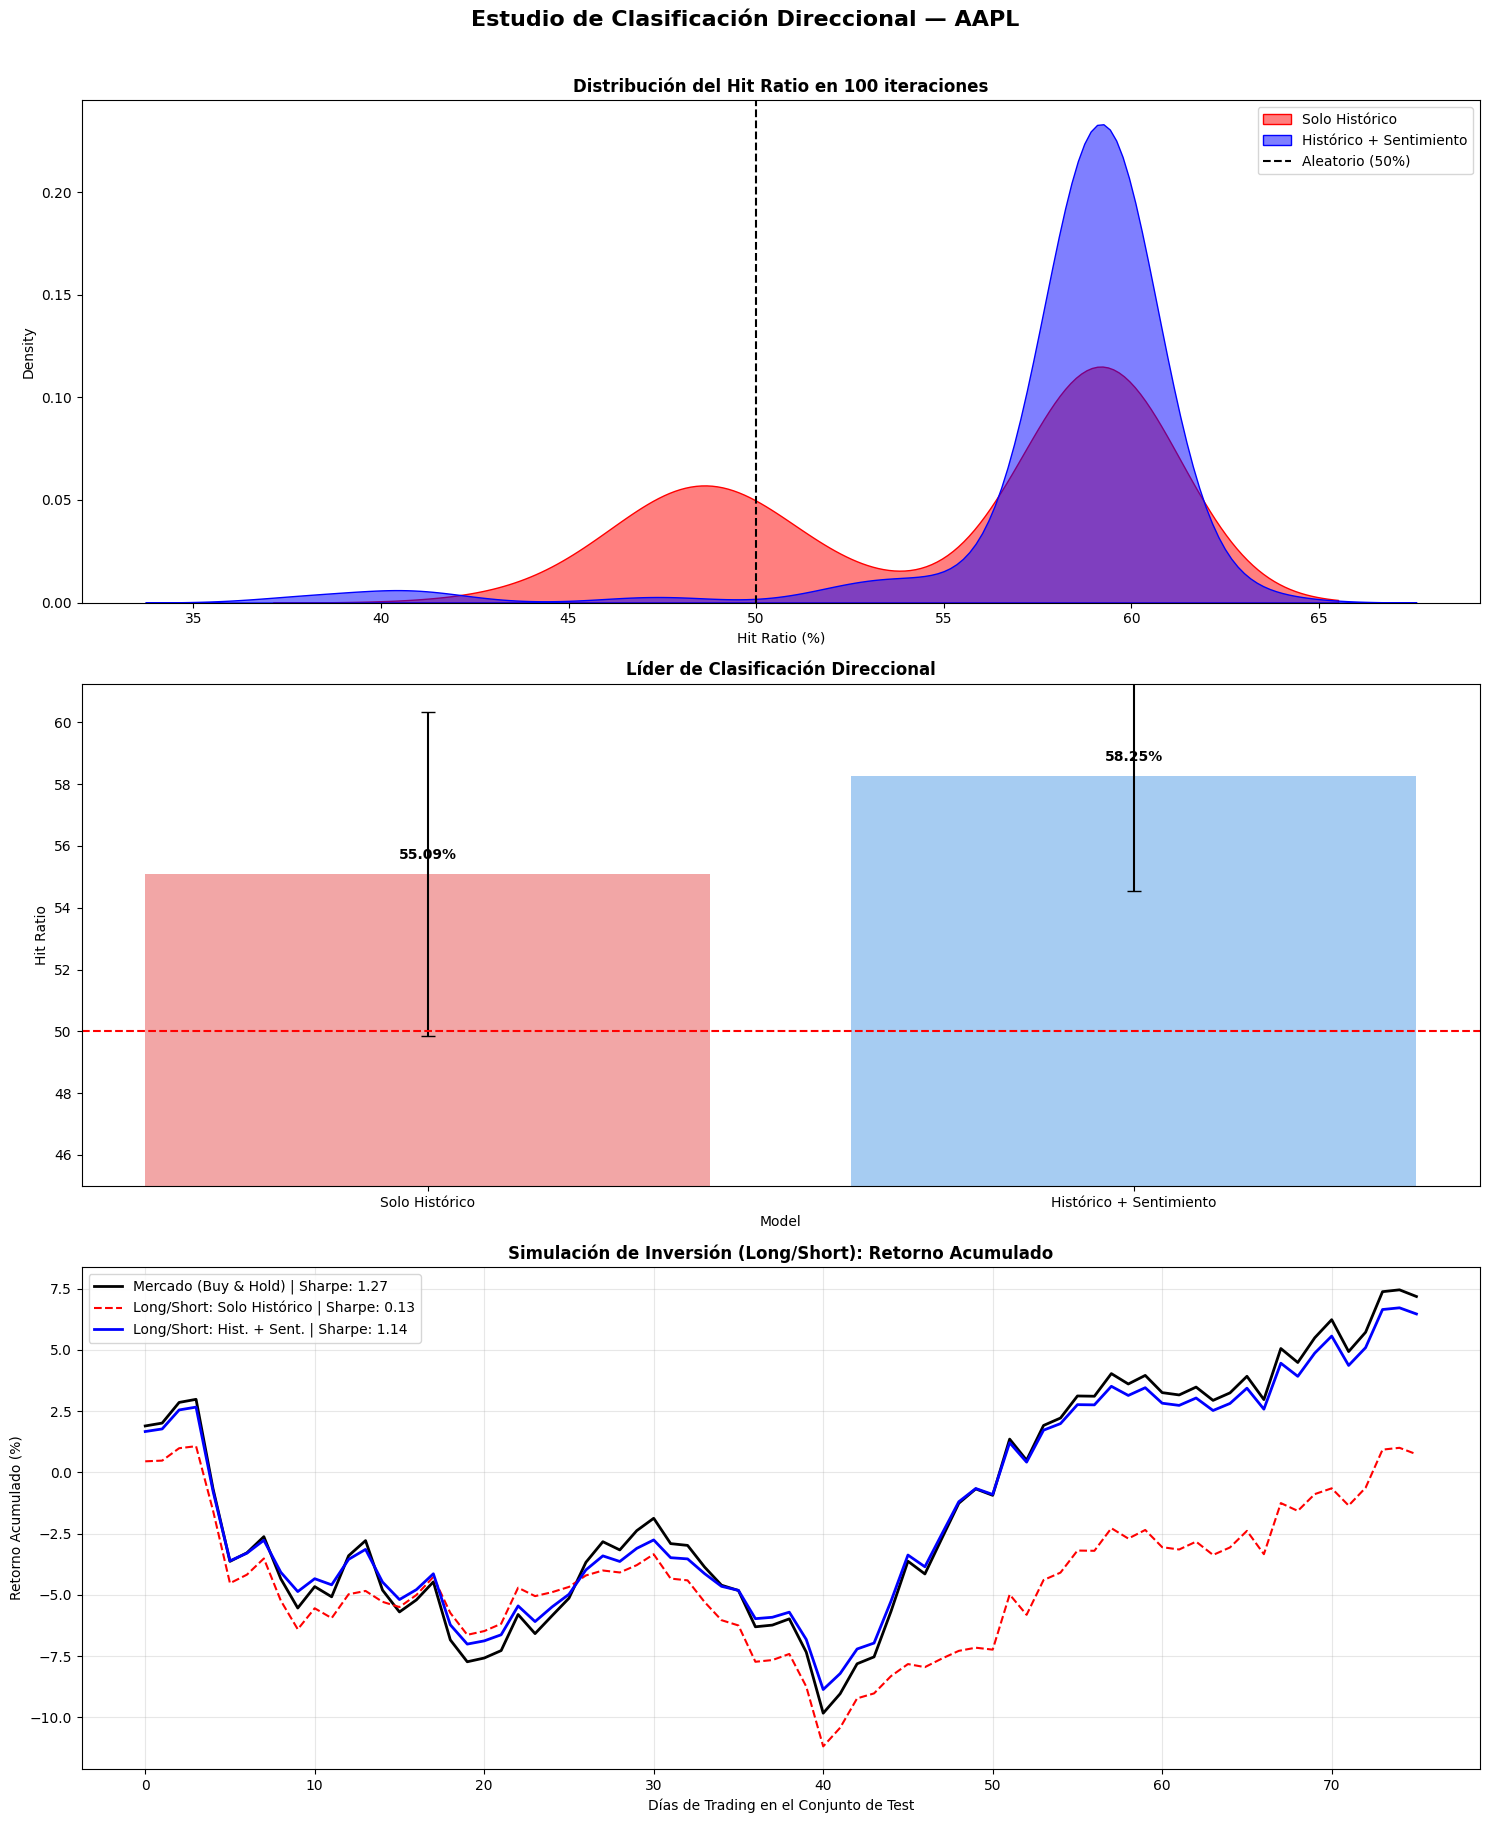

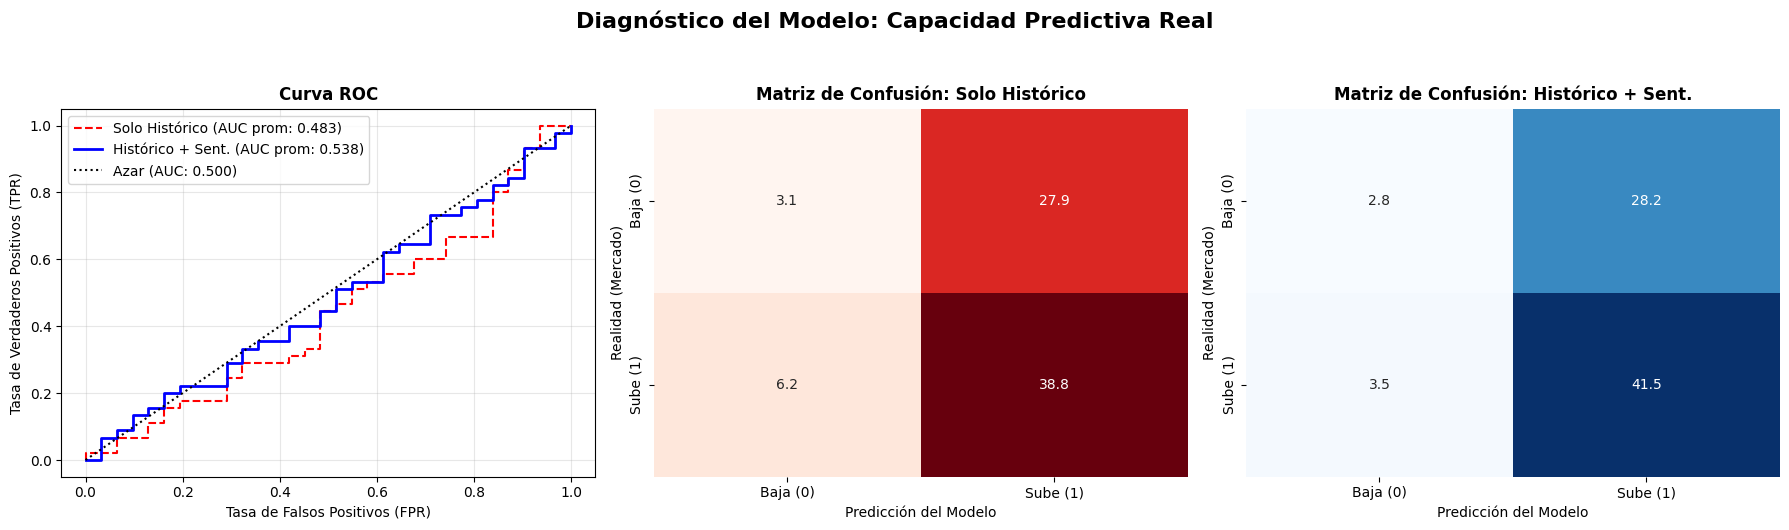

In [ ]:
RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_SENTIMIENTO,
    n_runs=100,
    window_size=10
)

### FinMultiTime, ventana = 10 y lambda = 0.03

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 39m 53s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.09% |     57.85% |     86.22% |     68.69%
Multivariante (Hist + Sent)  |     58.30% |     58.57% |     95.60% |     72.32%

RESUMEN DE MÉTRICAS FI

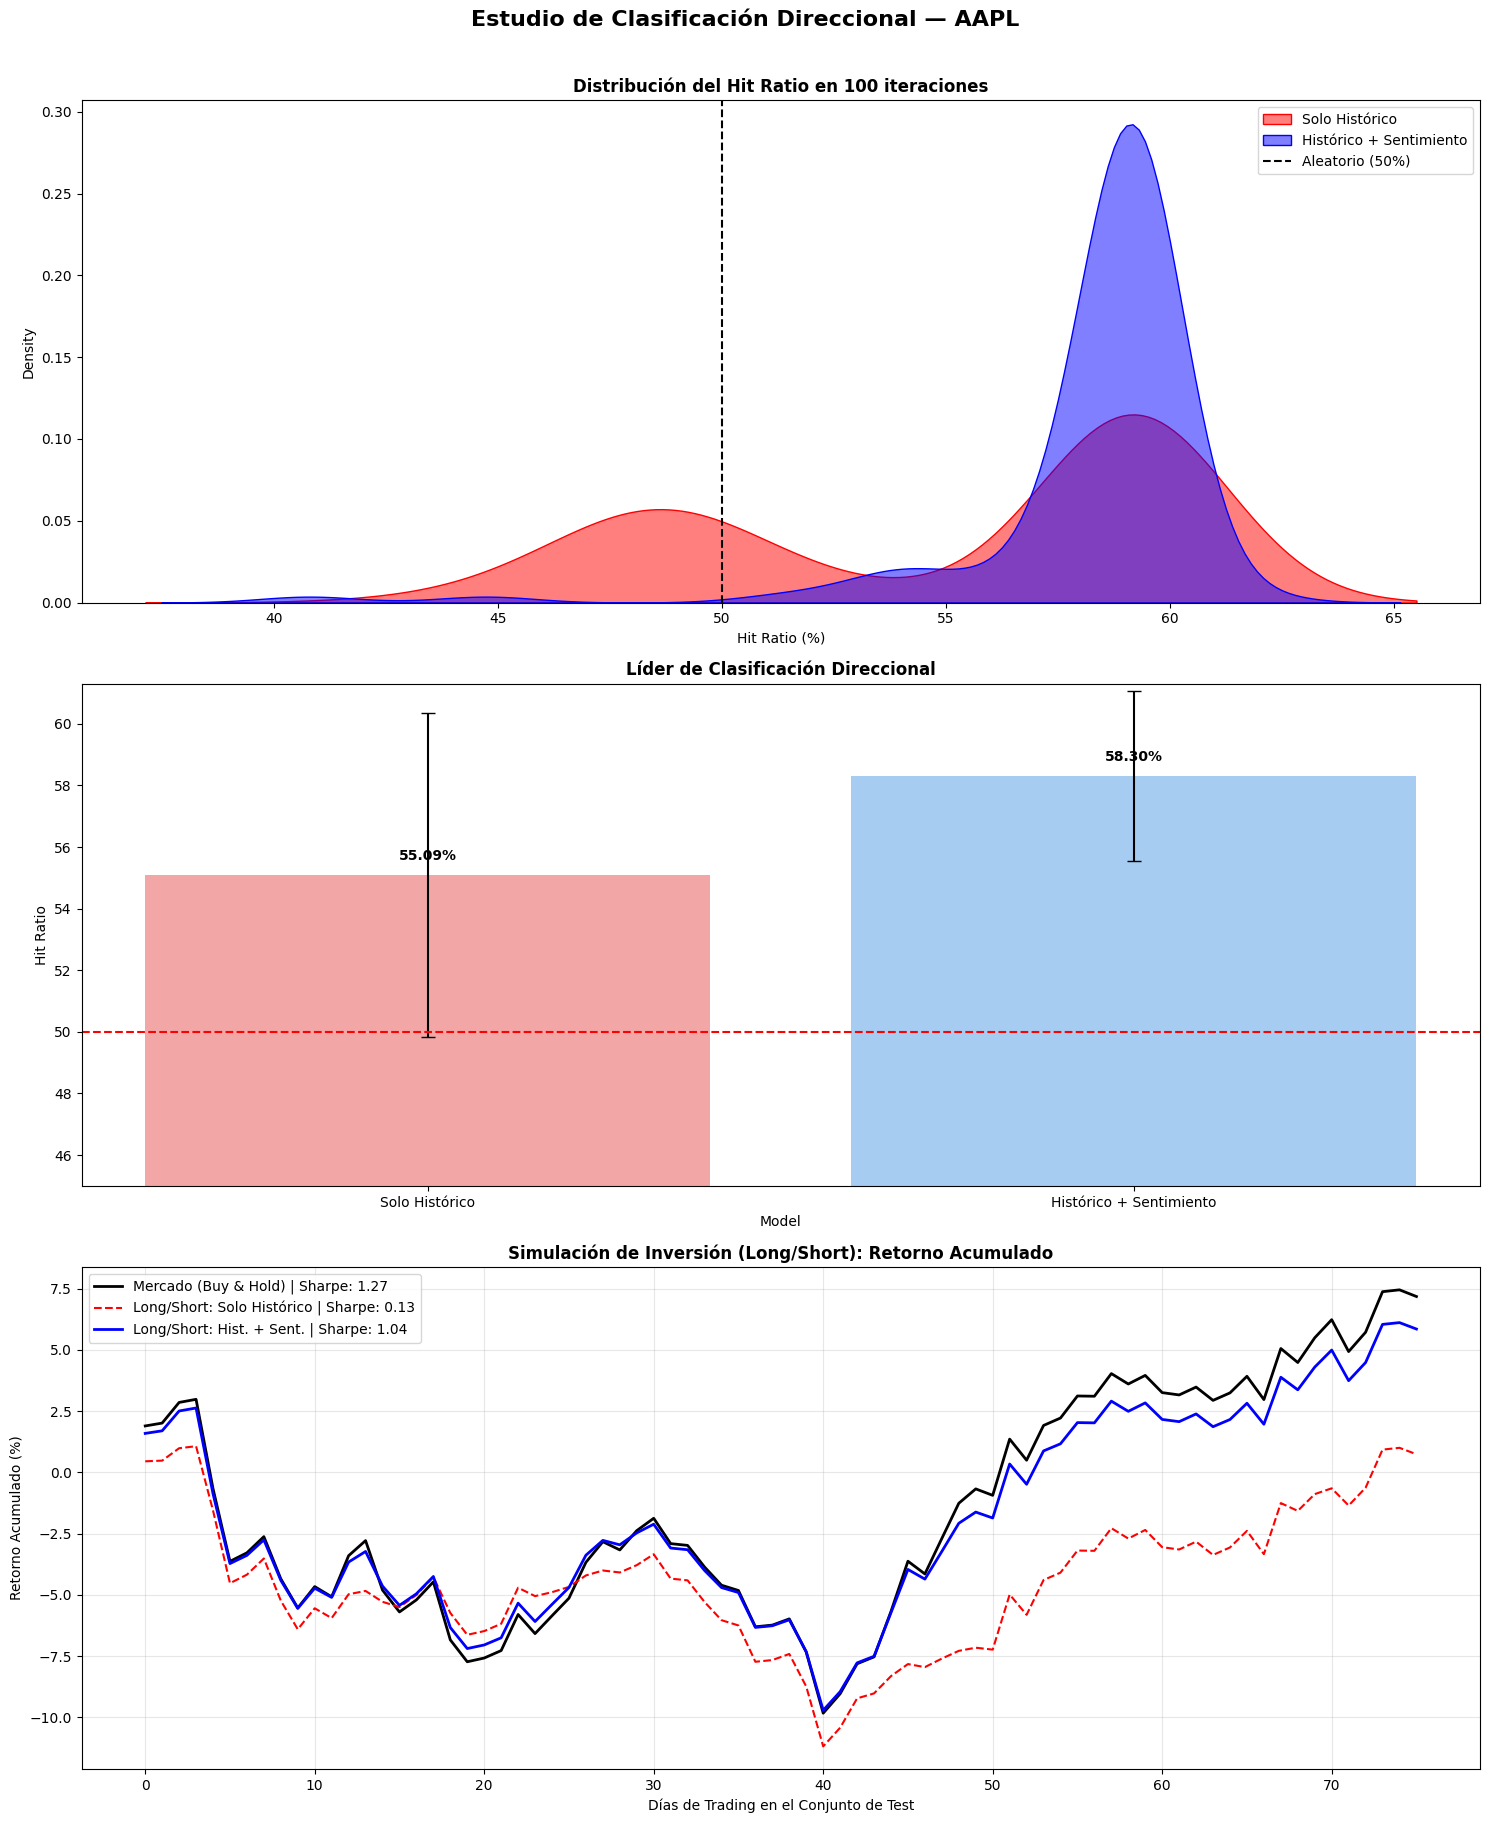

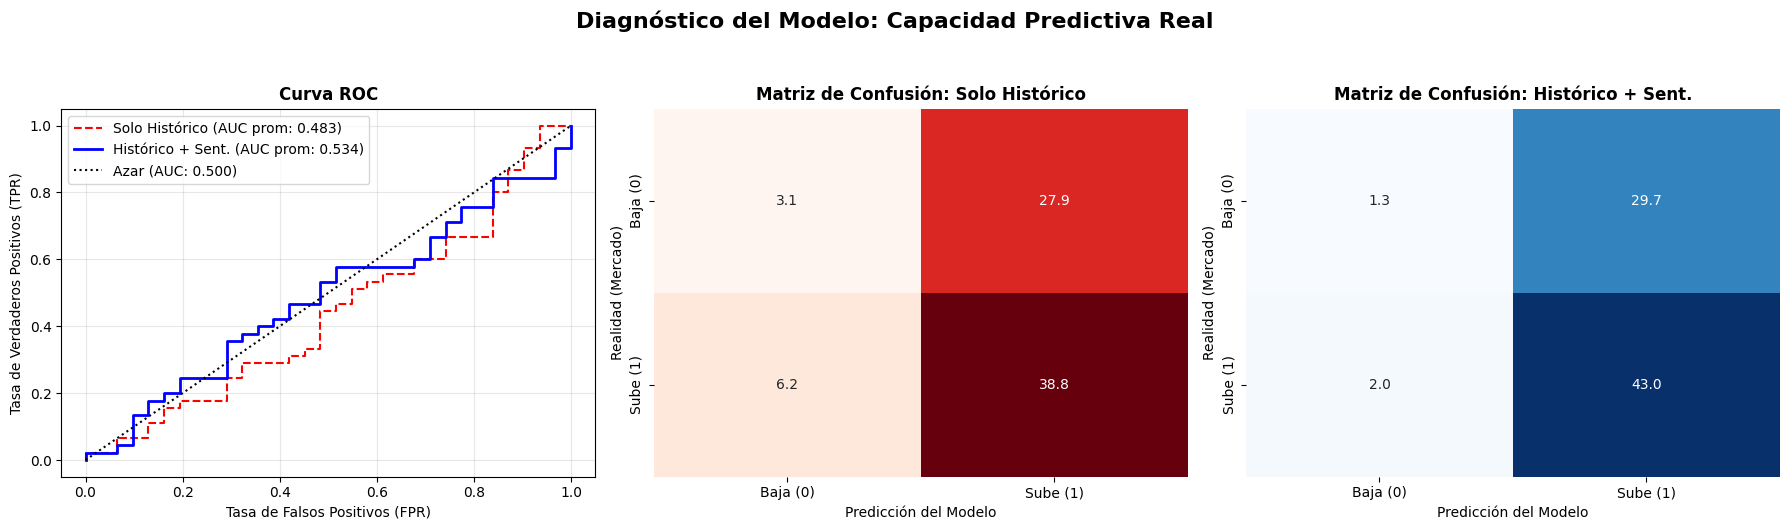

In [ ]:
RUTA_2 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_2,
    n_runs=100,
    window_size=10
)

### FNSPID, ventana = 15 y lambda = 0.1

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 33m 43s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     58.67% |     58.67% |    100.00% |     73.95%
Multivariante (Hist + Sent)  |     51.40% |     56.00% |     71.11% |     61.15%

RESUMEN DE MÉTRICAS FINANCIERAS
Estrategia / Modelo                 |    Sharpe Ratio |    Max D

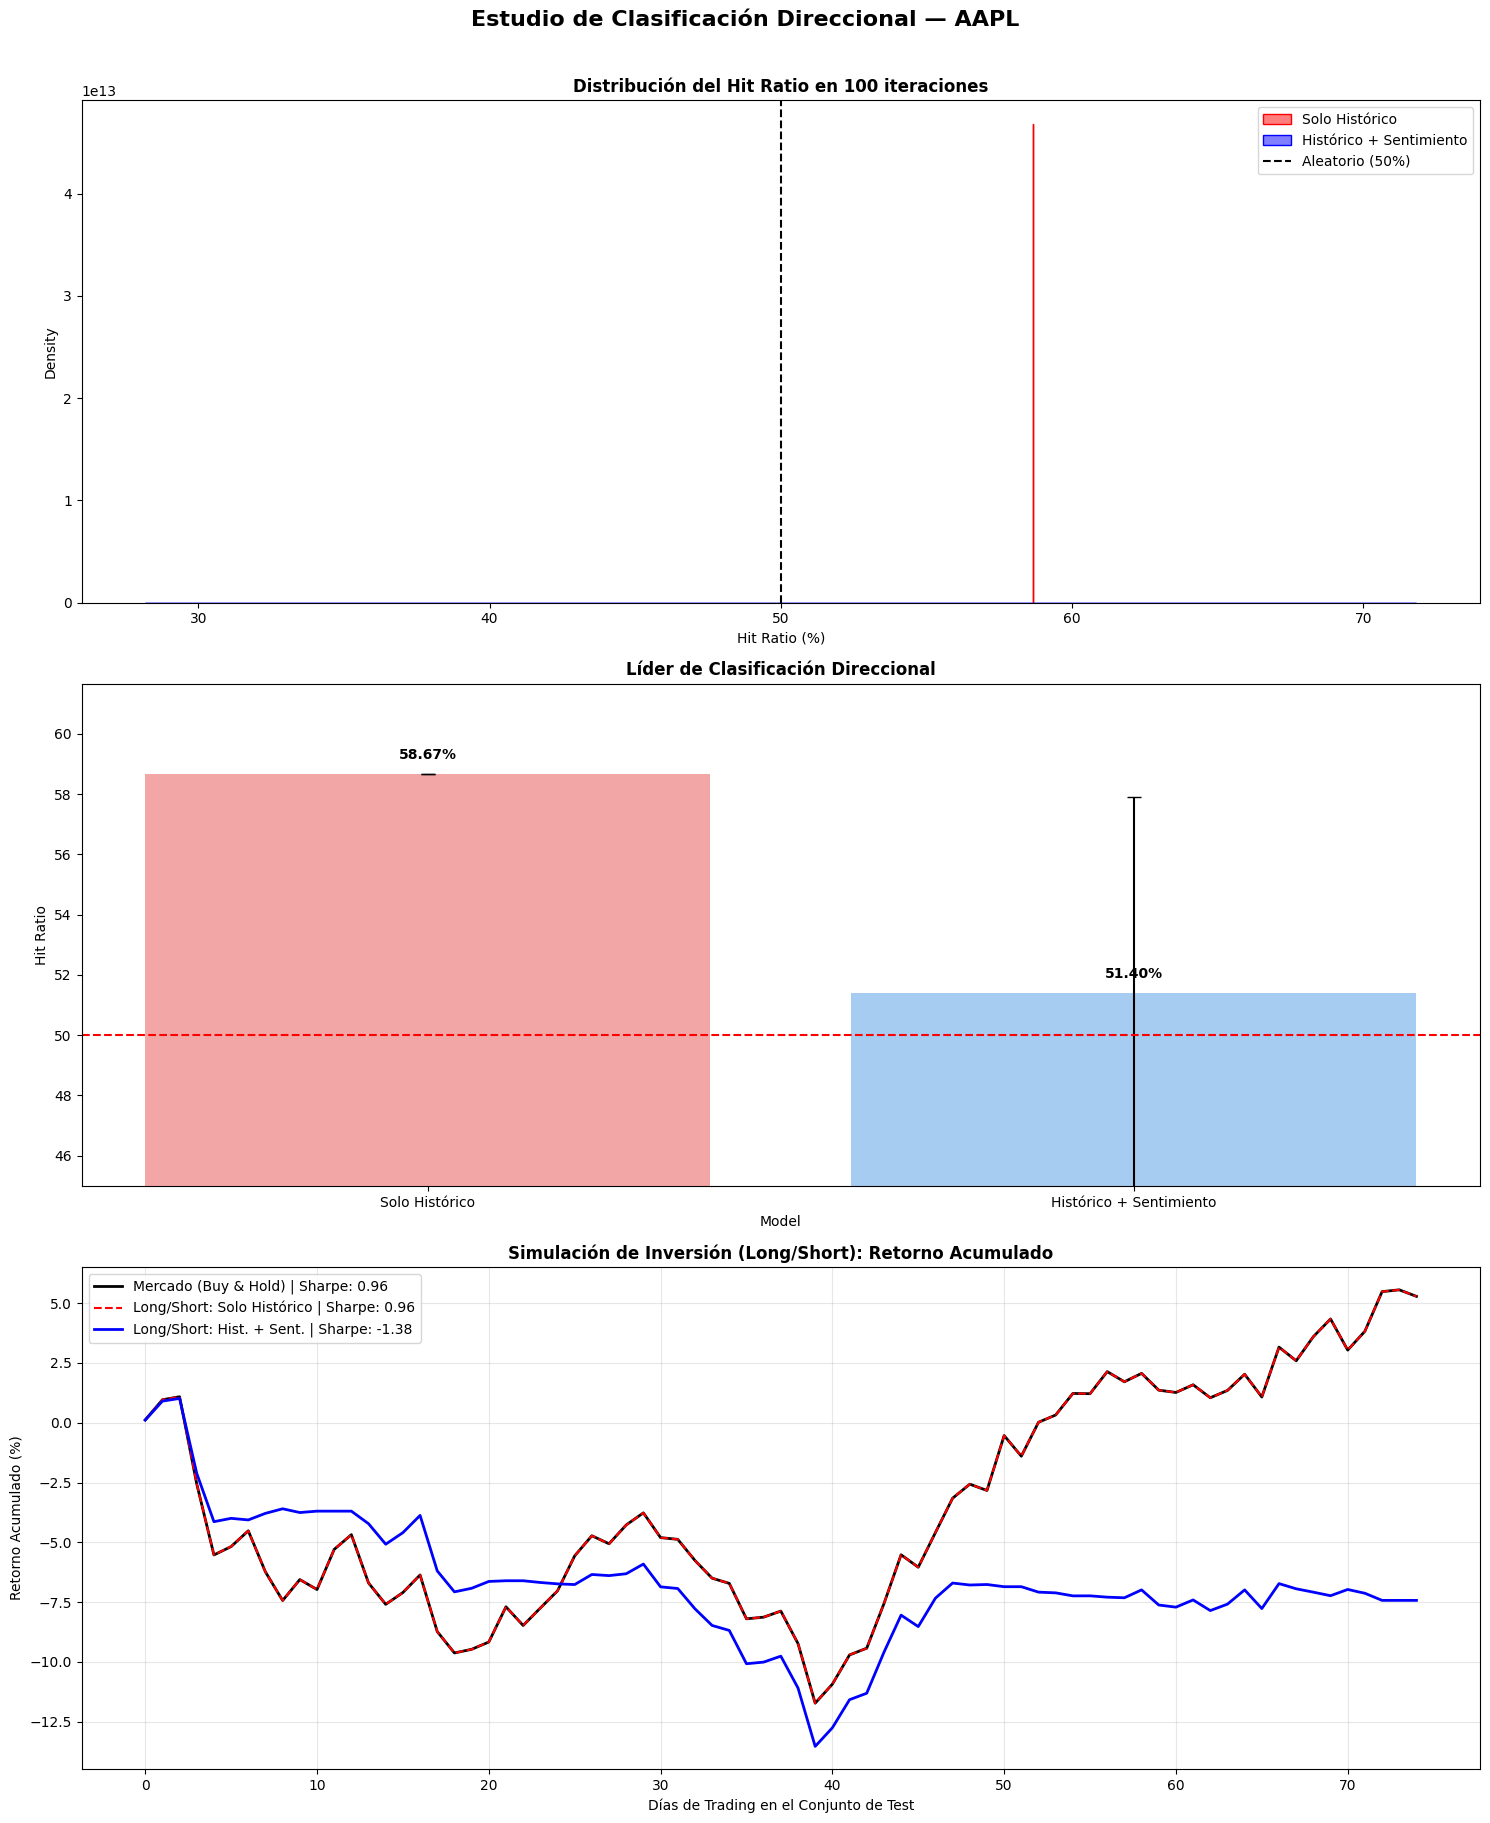

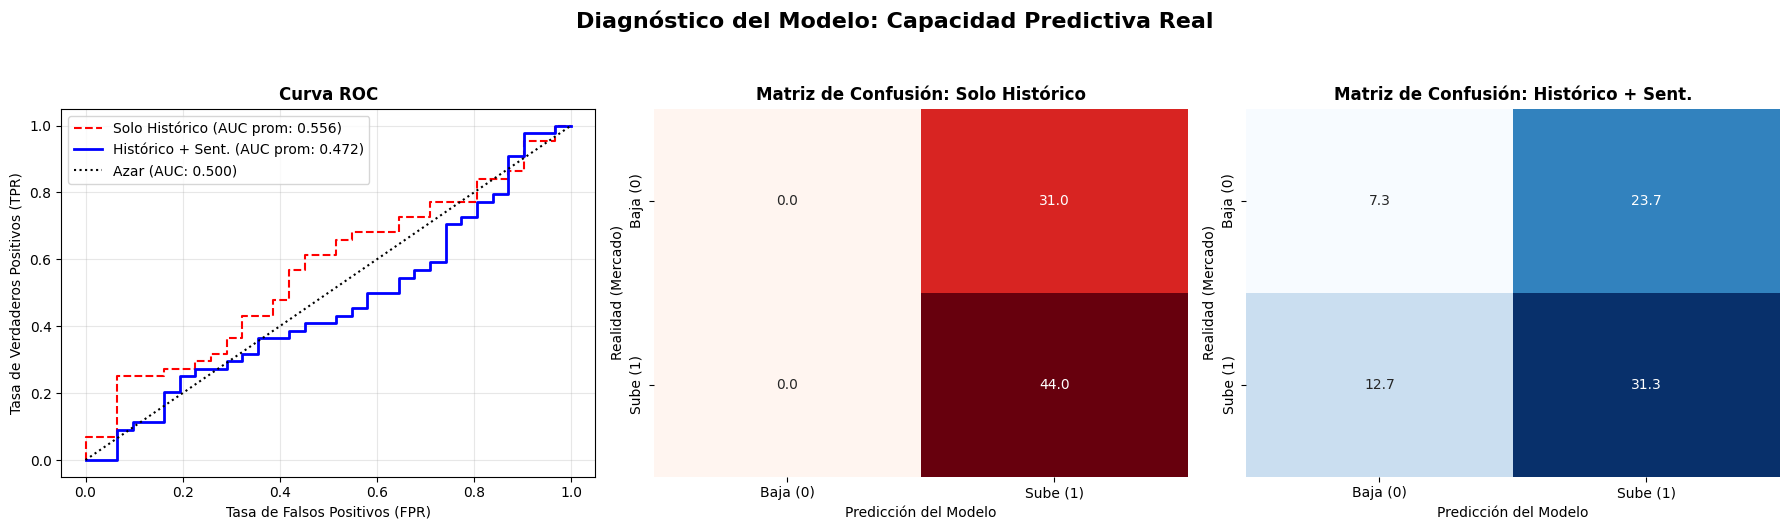

In [ ]:
RUTA_3 = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM_lam01.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_3,
    n_runs=100,
    window_size=15
)

### FinnMultiTime, ventana = 15 y lambda = 0.1

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA AAPL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 39m 56s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     58.67% |     58.67% |    100.00% |     73.95%
Multivariante (Hist + Sent)  |     58.57% |     58.65% |     99.57% |     73.78%

RESUMEN DE MÉTRICAS FI

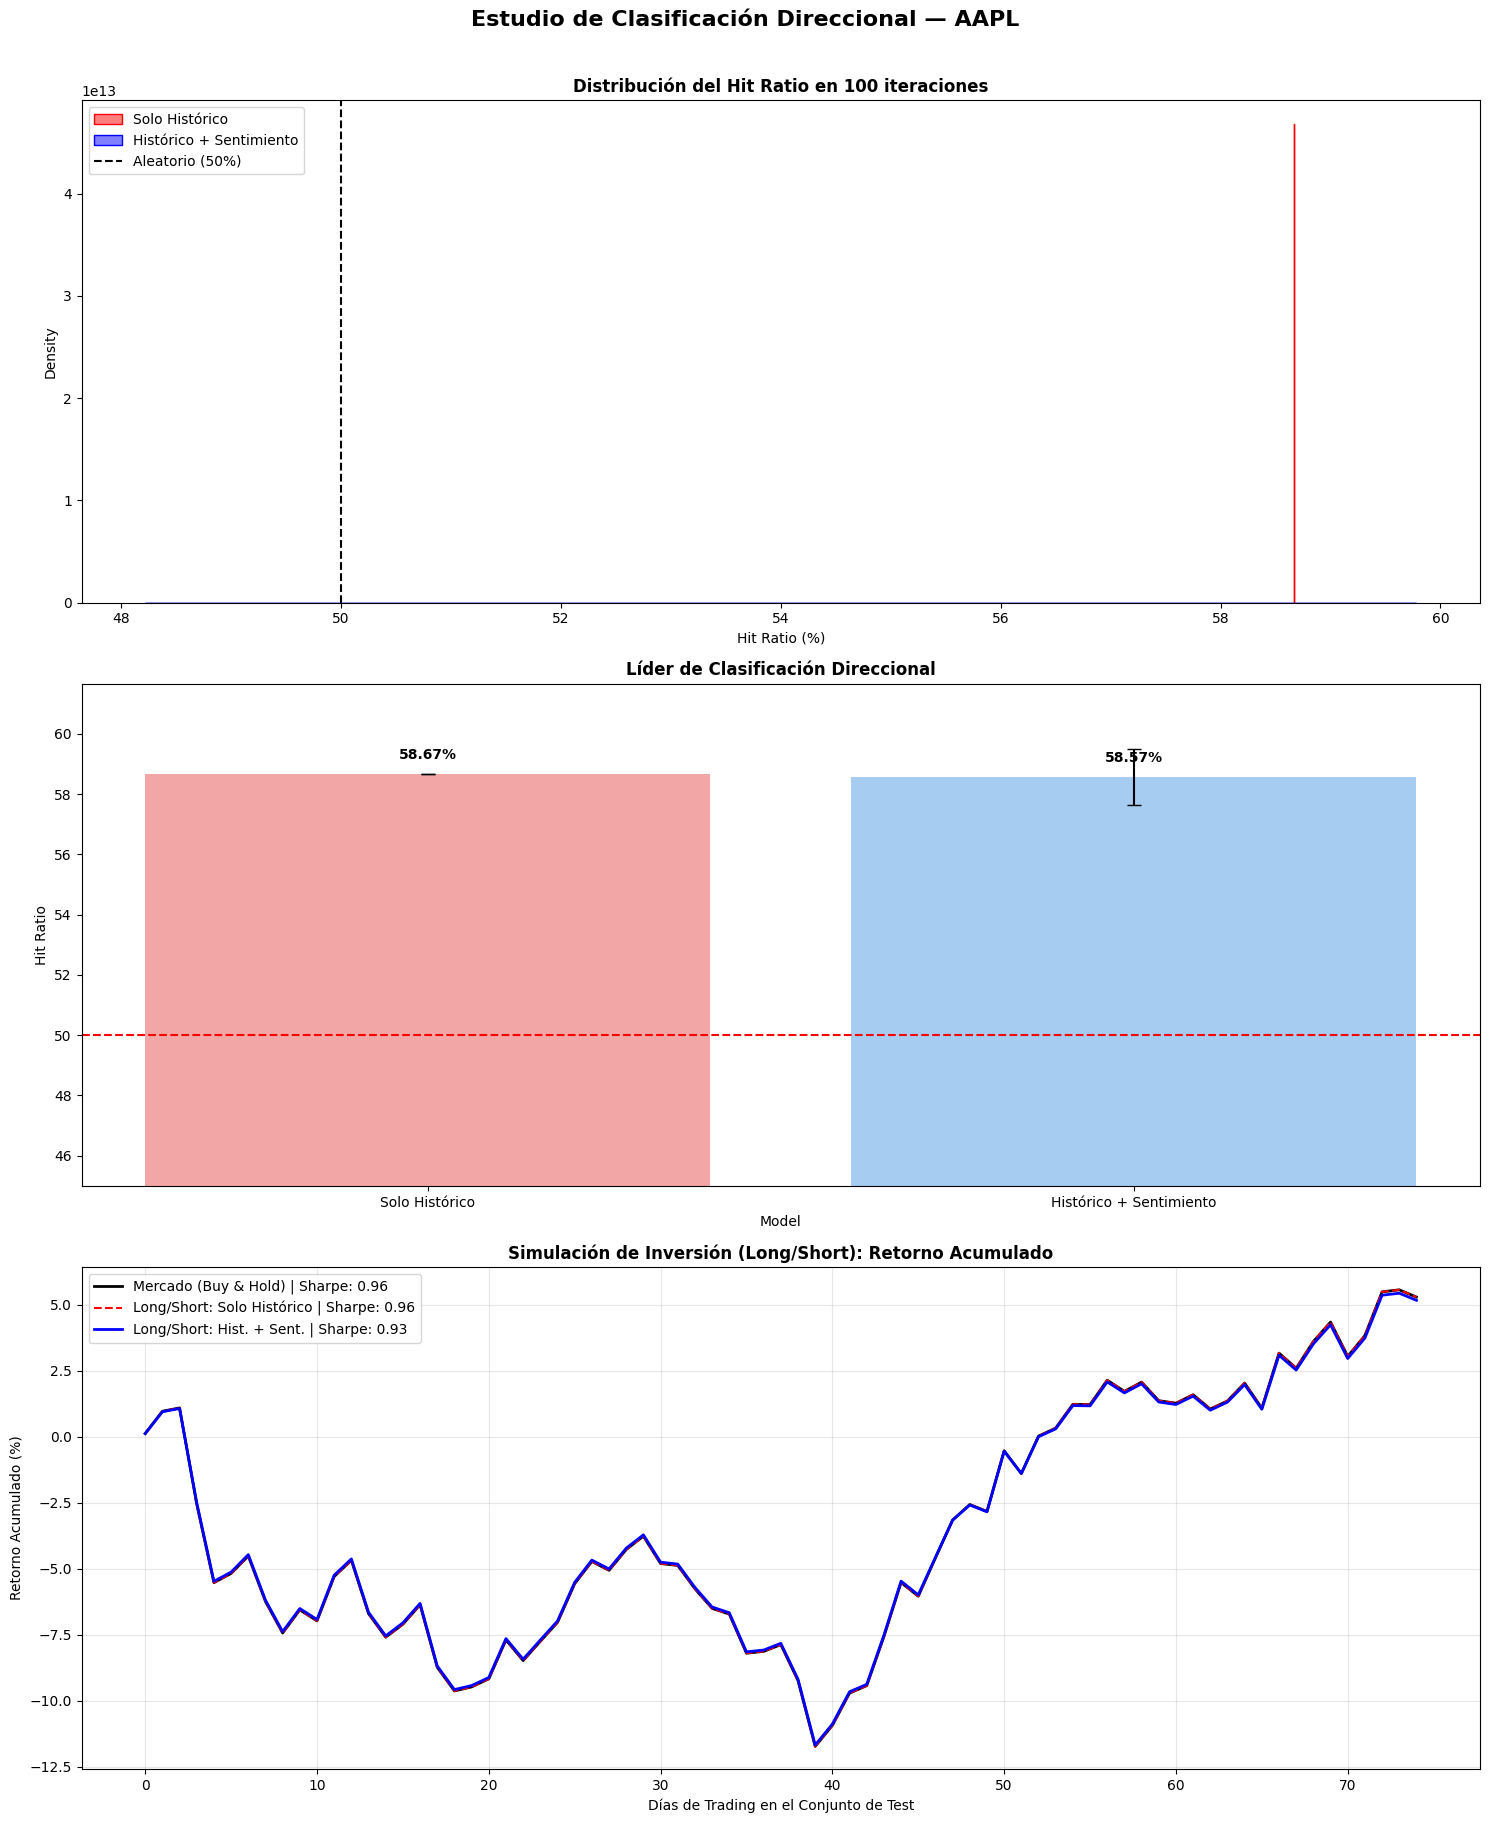

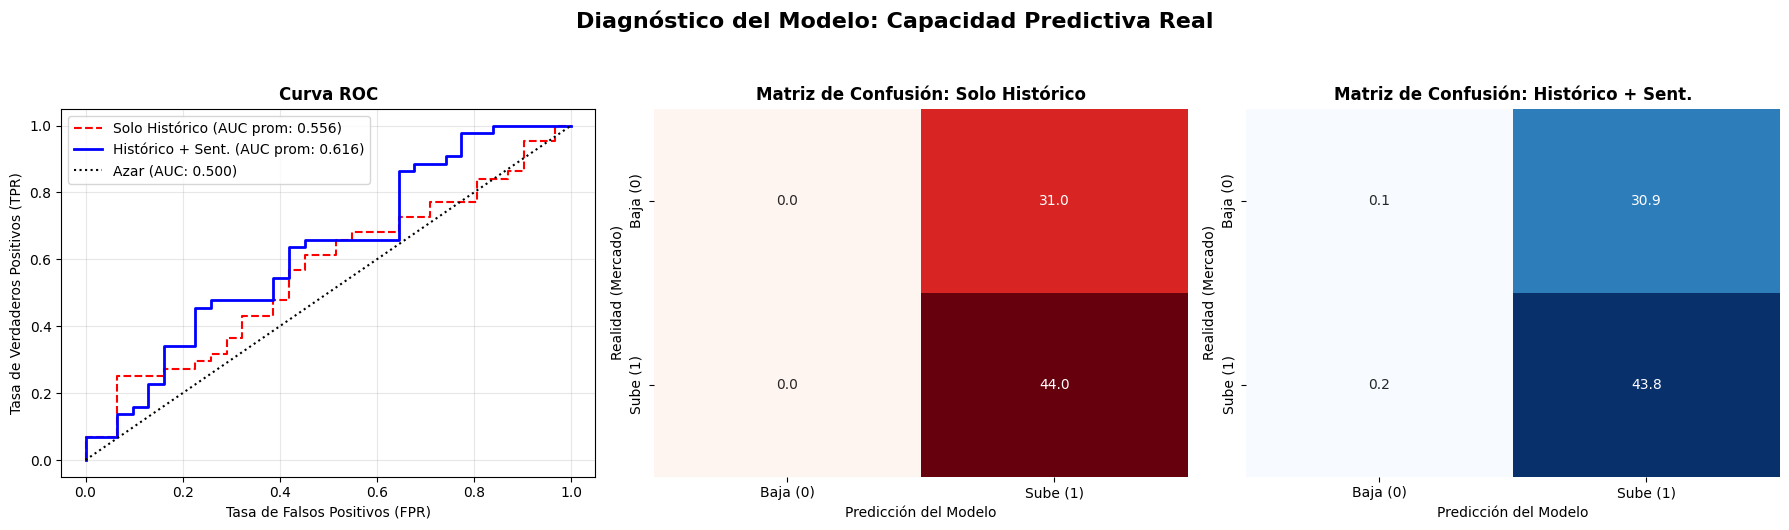

In [ ]:
RUTA_4 = '/content/drive/MyDrive/GIA/TFG/FinnMultiTime_SeriesTemporales_LSTM_lam01.parquet'

experimento_clasificacion_direcional(
    ticker_elegido="AAPL",
    ruta_sentimiento=RUTA_4,
    n_runs=100,
    window_size=15
)

## Probamos con distintos ticker - FNSPID

- Comenzamos con NVDIA, tamaño ventana = 10 y lambda = 0.1

In [ ]:
RUTA_SENTIMIENTO = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM.parquet'
RUTA_3 = '/content/drive/MyDrive/GIA/TFG/fnspid_resumenes_LSTM_lam01.parquet'

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA NVDA


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 30m 1s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.17% |     55.17% |    100.00% |     71.11%
Multivariante (Hist + Sent)  |     53.56% |     52.27% |     84.47% |     62.26%

RESUMEN DE MÉTRICAS FINANCIERAS
Estrategia / Modelo                 |    Sharpe Ratio |    Max Dr

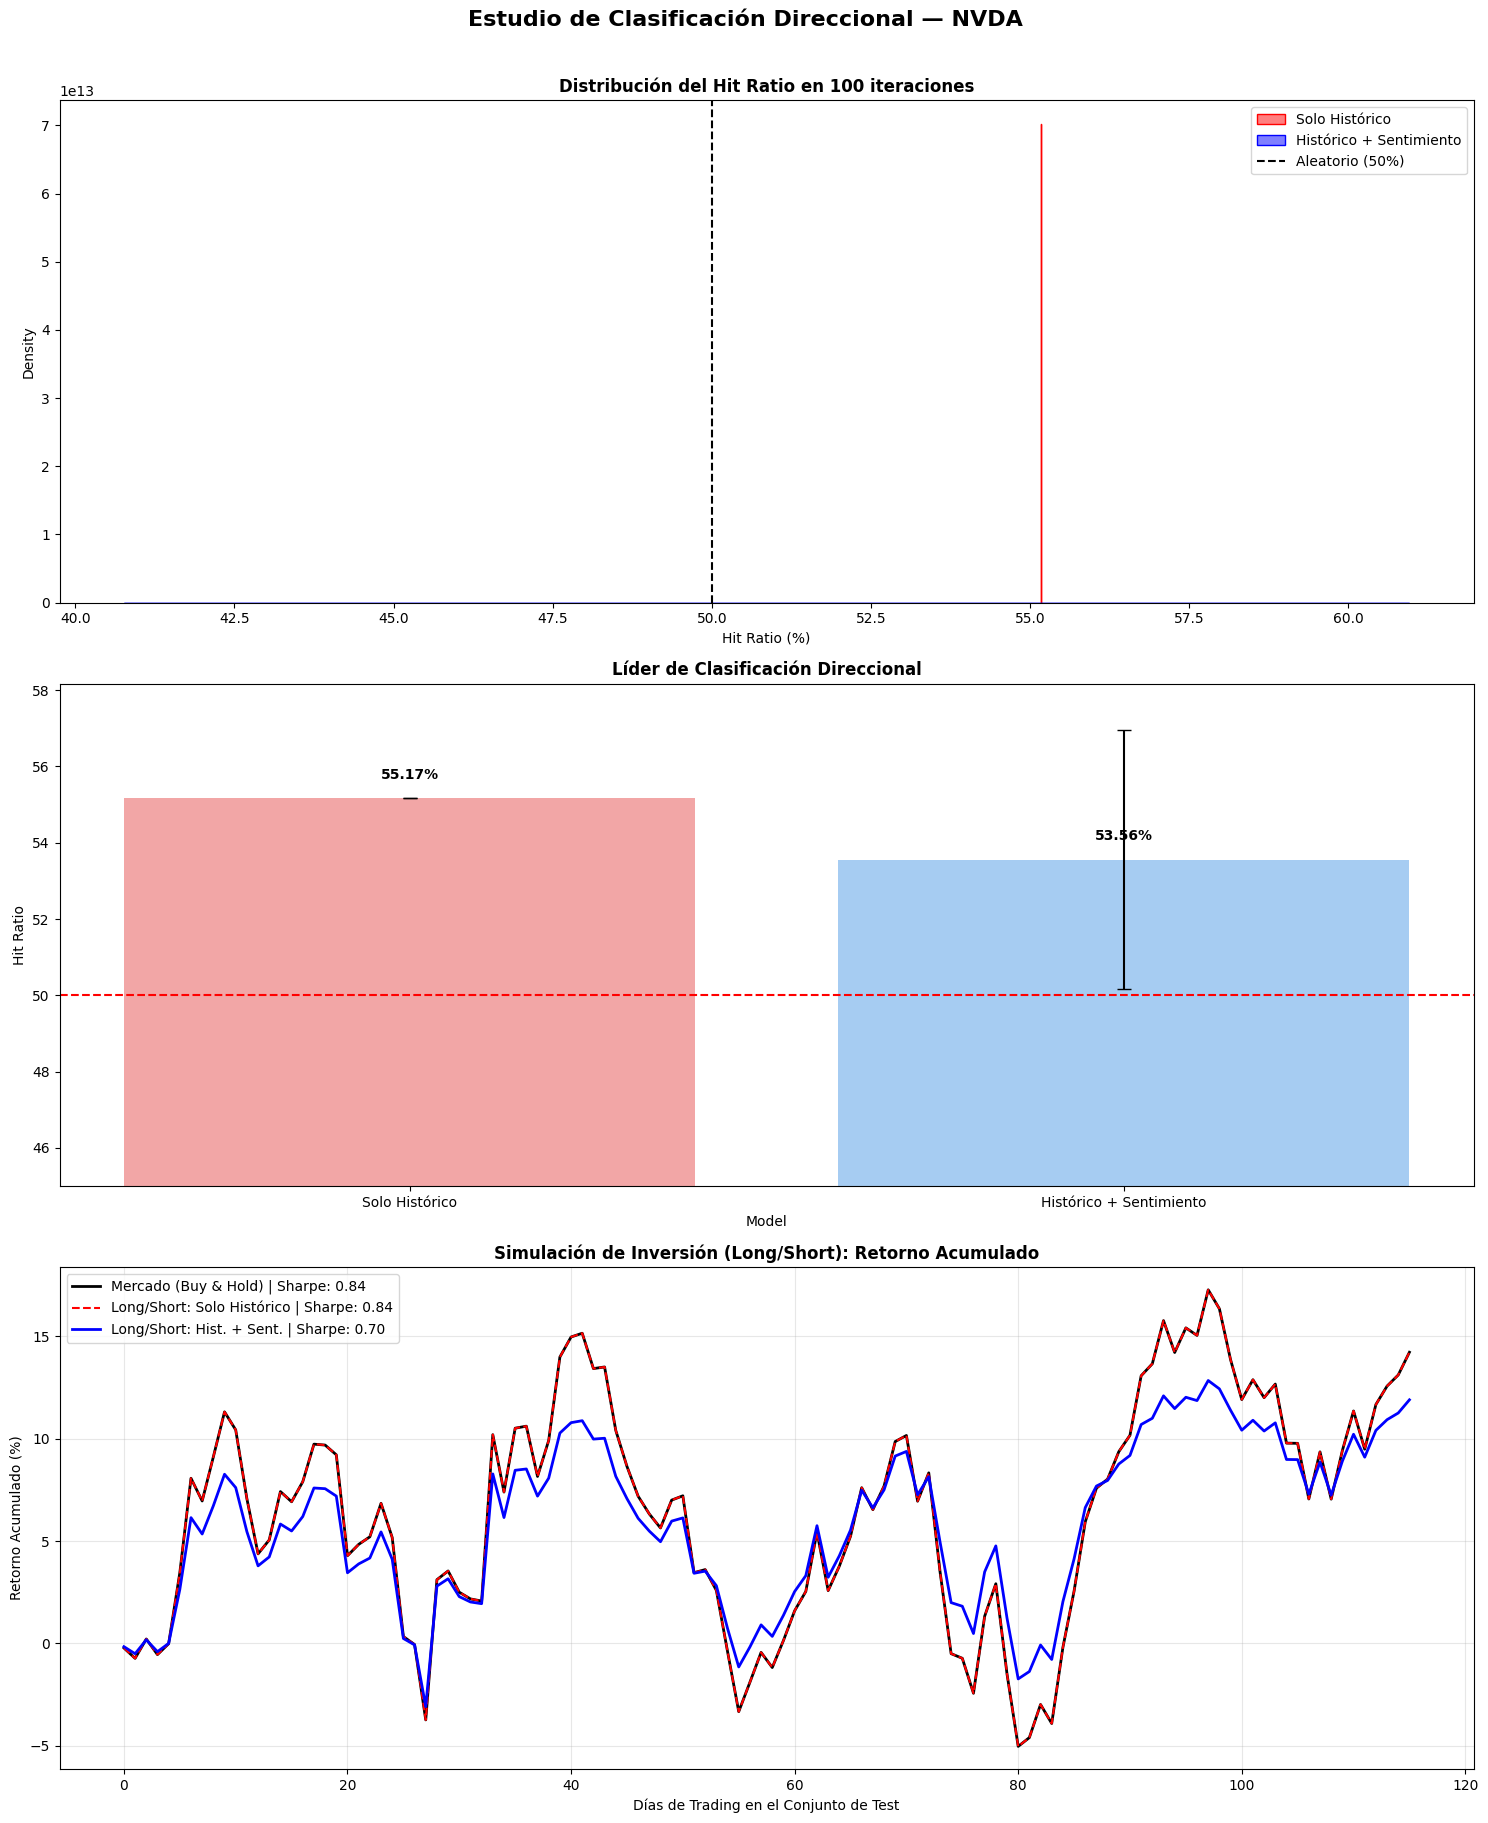

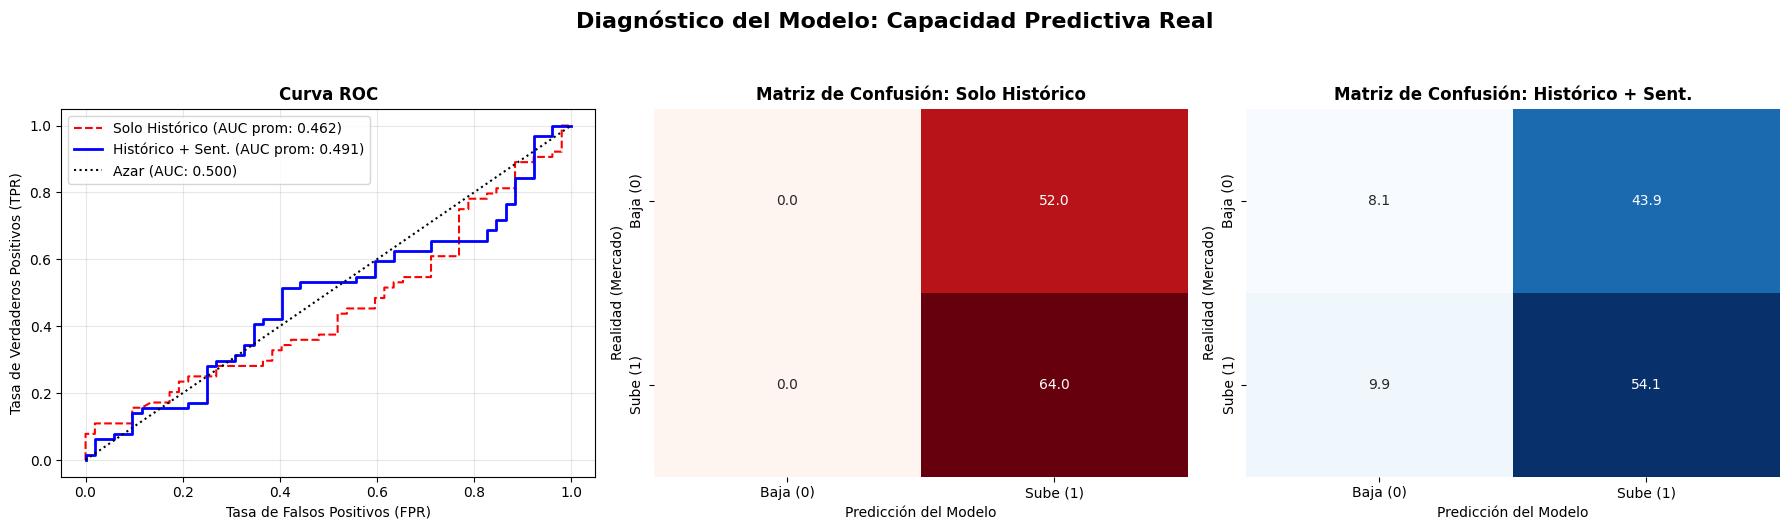

In [ ]:
experimento_clasificacion_direcional(
    ticker_elegido="NVDA",
    ruta_sentimiento=RUTA_SENTIMIENTO,
    n_runs=100,
    window_size=10
)

- ORACLE, tamaño ventana = 10 y lambda = 0.1

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA ORCL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 67m 25s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     52.93% |     52.93% |     99.98% |     69.22%
Multivariante (Hist + Sent)  |     52.49% |     51.86% |     93.38% |     65.86%

RESUMEN DE MÉTRICAS FI

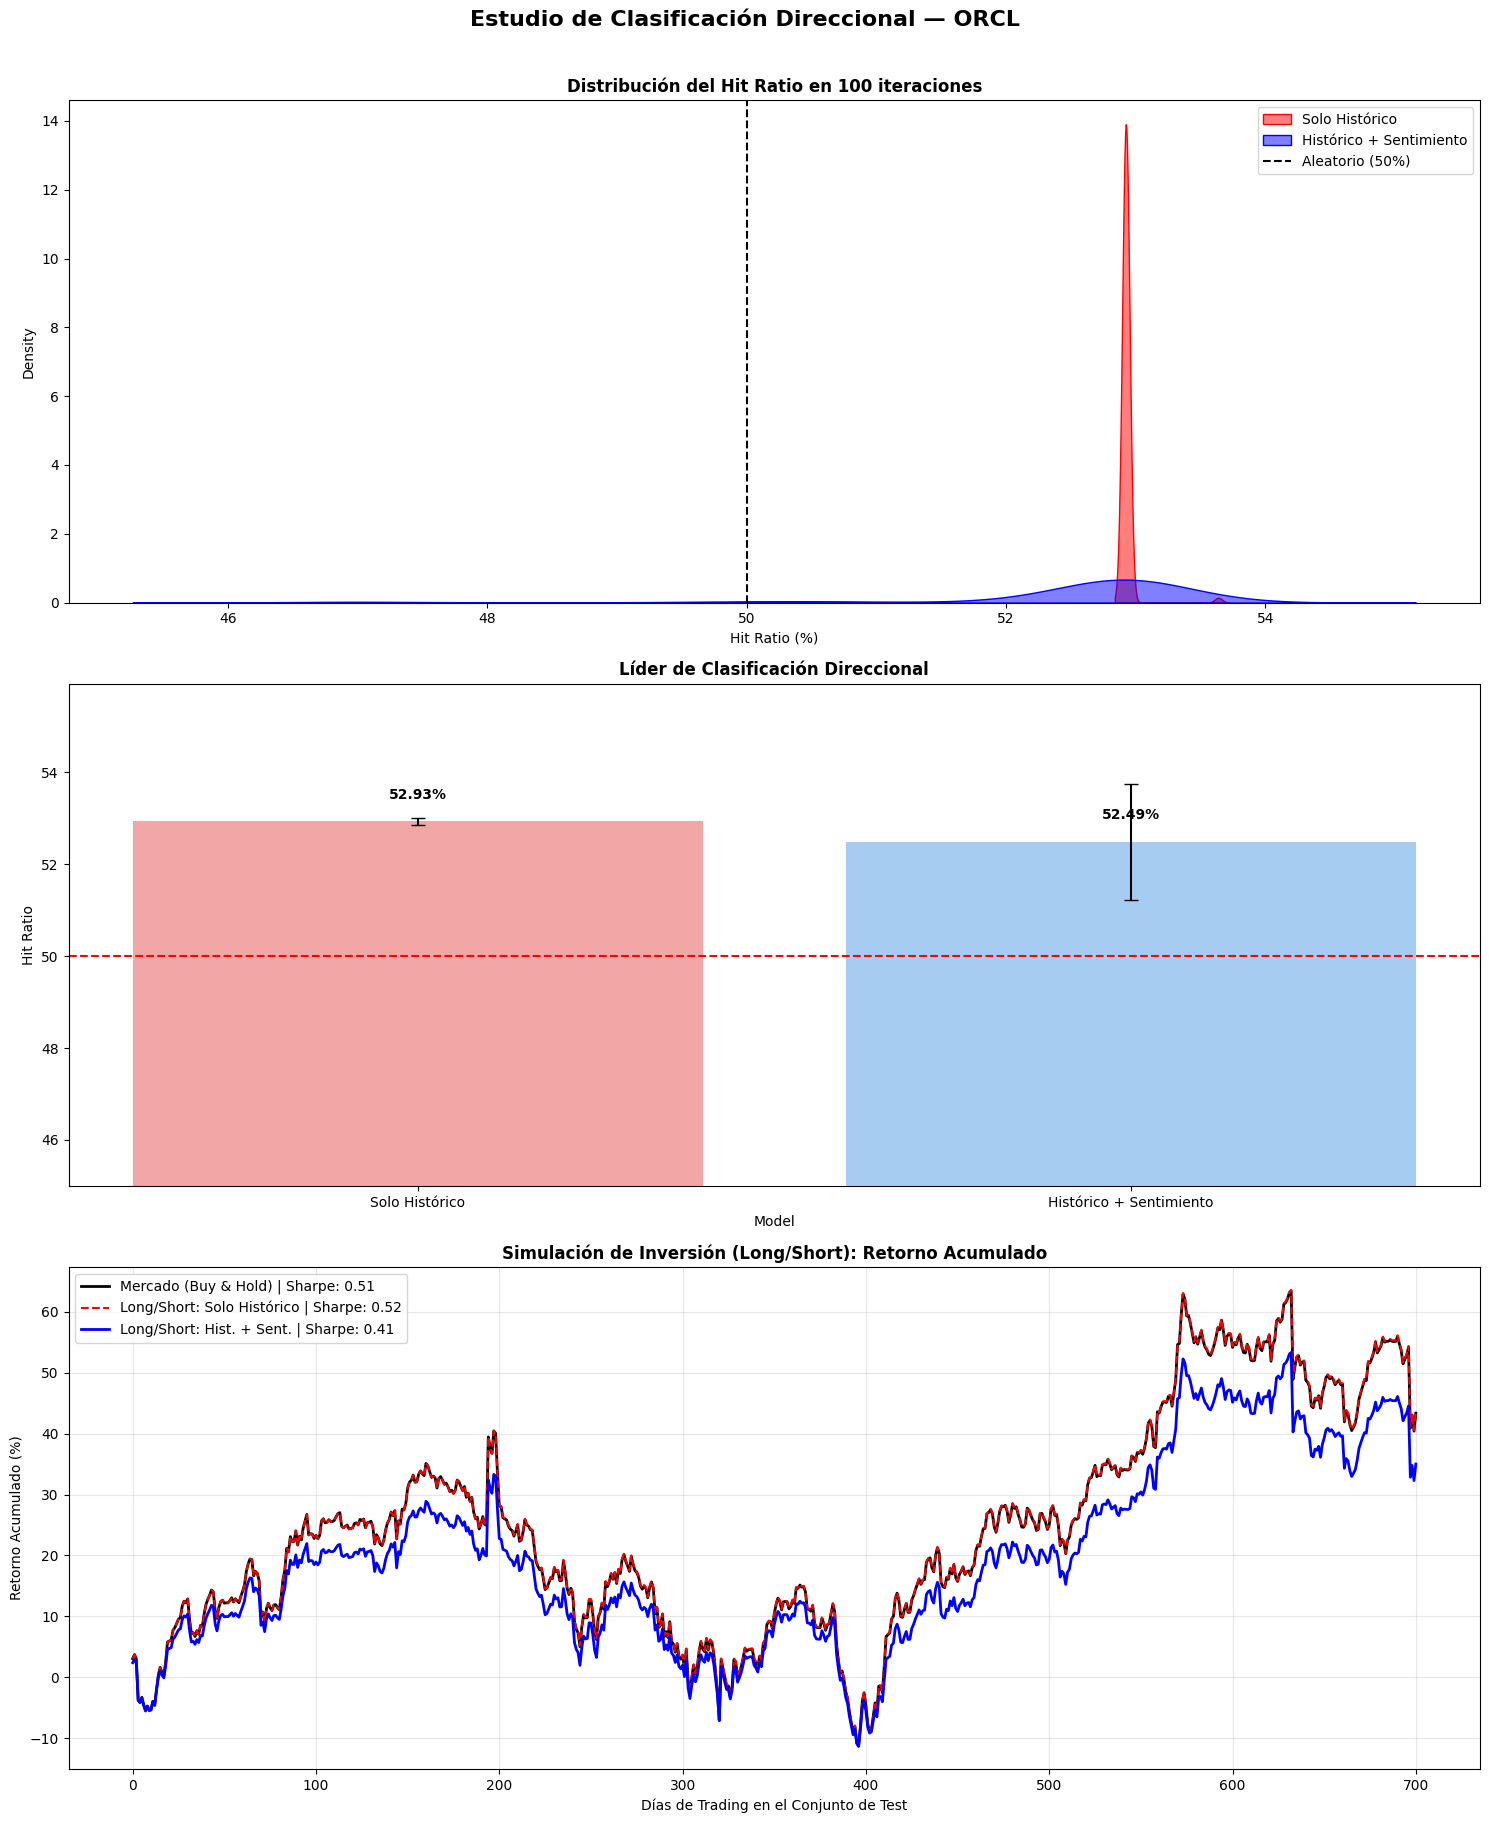

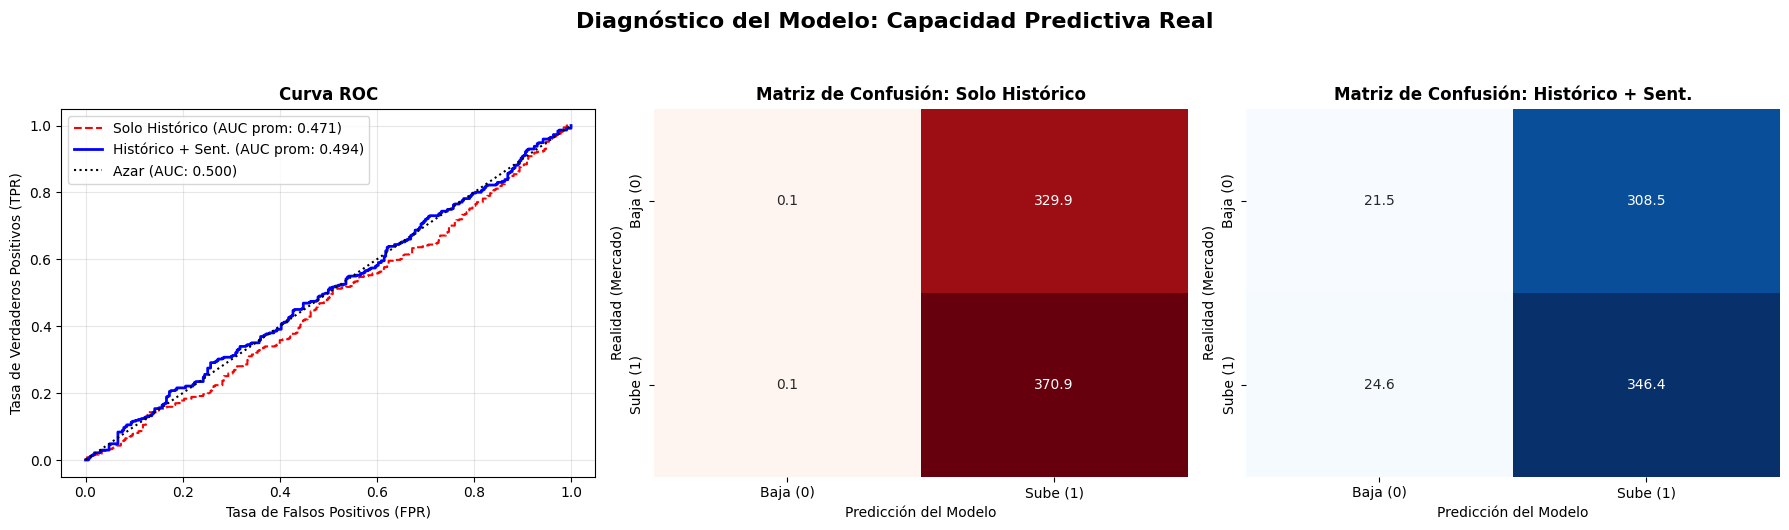

In [ ]:
experimento_clasificacion_direcional(
    ticker_elegido="ORCL",
    ruta_sentimiento=RUTA_SENTIMIENTO,
    n_runs=100,
    window_size=10
)

### Tamaño ventana 15 y lambda = 0.1 en otros tickers en FNSPID

- ORACLE

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA ORCL
   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 75m 29s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     52.86% |     52.86% |    100.00% |     69.16%
Multivariante (Hist + Sent)  |     52.67% |     52.24% |     96.92% |     67.48%

RESUMEN DE MÉTRICAS FI

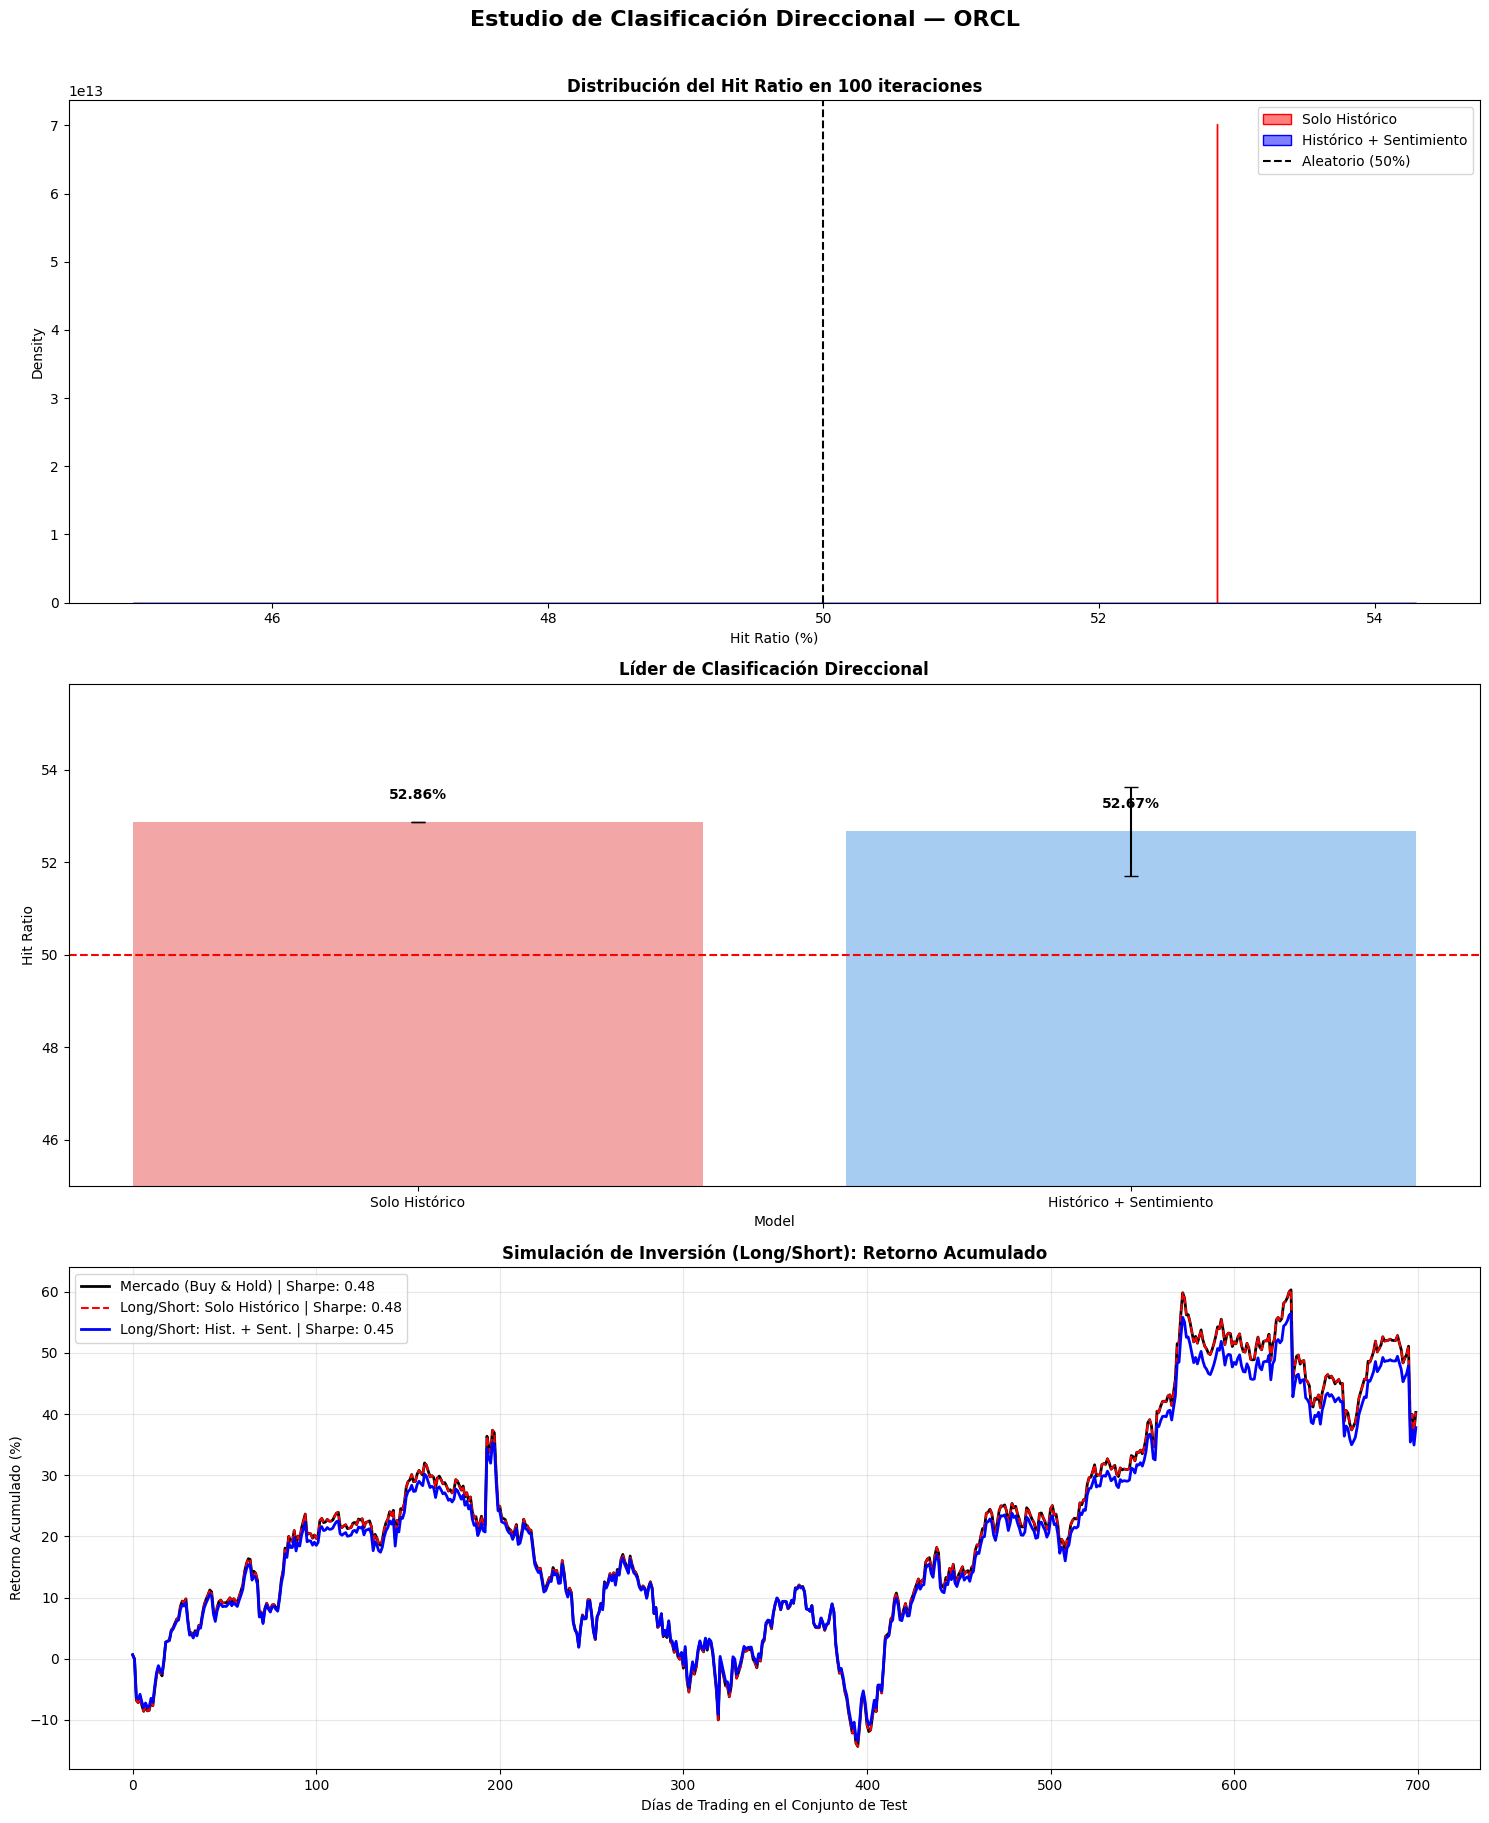

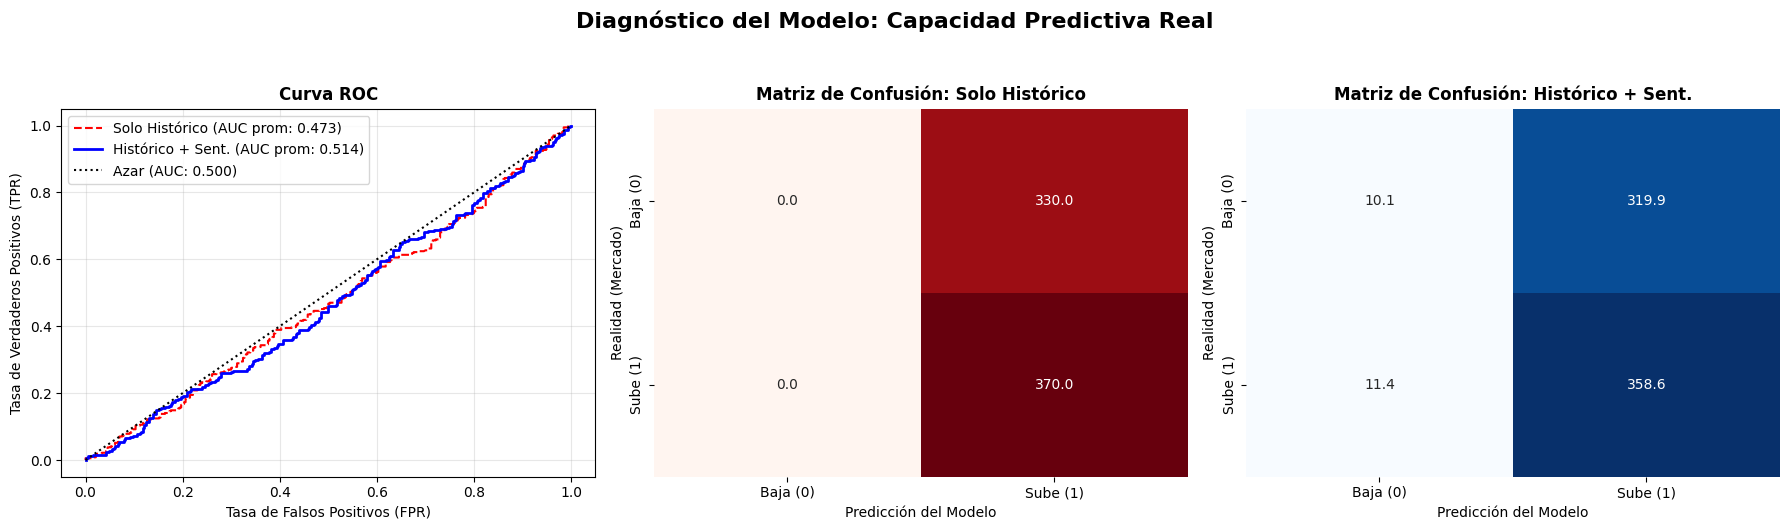

In [ ]:
experimento_clasificacion_direcional(
    ticker_elegido="ORCL",
    ruta_sentimiento=RUTA_3,
    n_runs=100,
    window_size=15
)

- NVIDIA

INICIANDO ESTUDIO: CLASIFICACIÓN DIRECCIONAL Y CURVA DE CAPITAL PARA NVDA


   [Progreso] Completadas 10/100 ejecuciones...
   [Progreso] Completadas 20/100 ejecuciones...
   [Progreso] Completadas 30/100 ejecuciones...
   [Progreso] Completadas 40/100 ejecuciones...
   [Progreso] Completadas 50/100 ejecuciones...
   [Progreso] Completadas 60/100 ejecuciones...
   [Progreso] Completadas 70/100 ejecuciones...
   [Progreso] Completadas 80/100 ejecuciones...
   [Progreso] Completadas 90/100 ejecuciones...
   [Progreso] Completadas 100/100 ejecuciones...

Experimento completado en 37m 58s

RESUMEN DE MÉTRICAS PREDICTIVAS (Promedio de las iteraciones)
Modelo                       |  Hit Ratio |  Precision |     Recall |   F1-Score
--------------------------------------------------------------------------------
Univariante (Solo Hist.)     |     55.10% |     53.41% |     95.27% |     68.35%
Multivariante (Hist + Sent)  |     52.29% |     59.38% |     45.09% |     50.07%

RESUMEN DE MÉTRICAS FINANCIERAS
Estrategia / Modelo                 |    Sharpe Ratio |    Max D

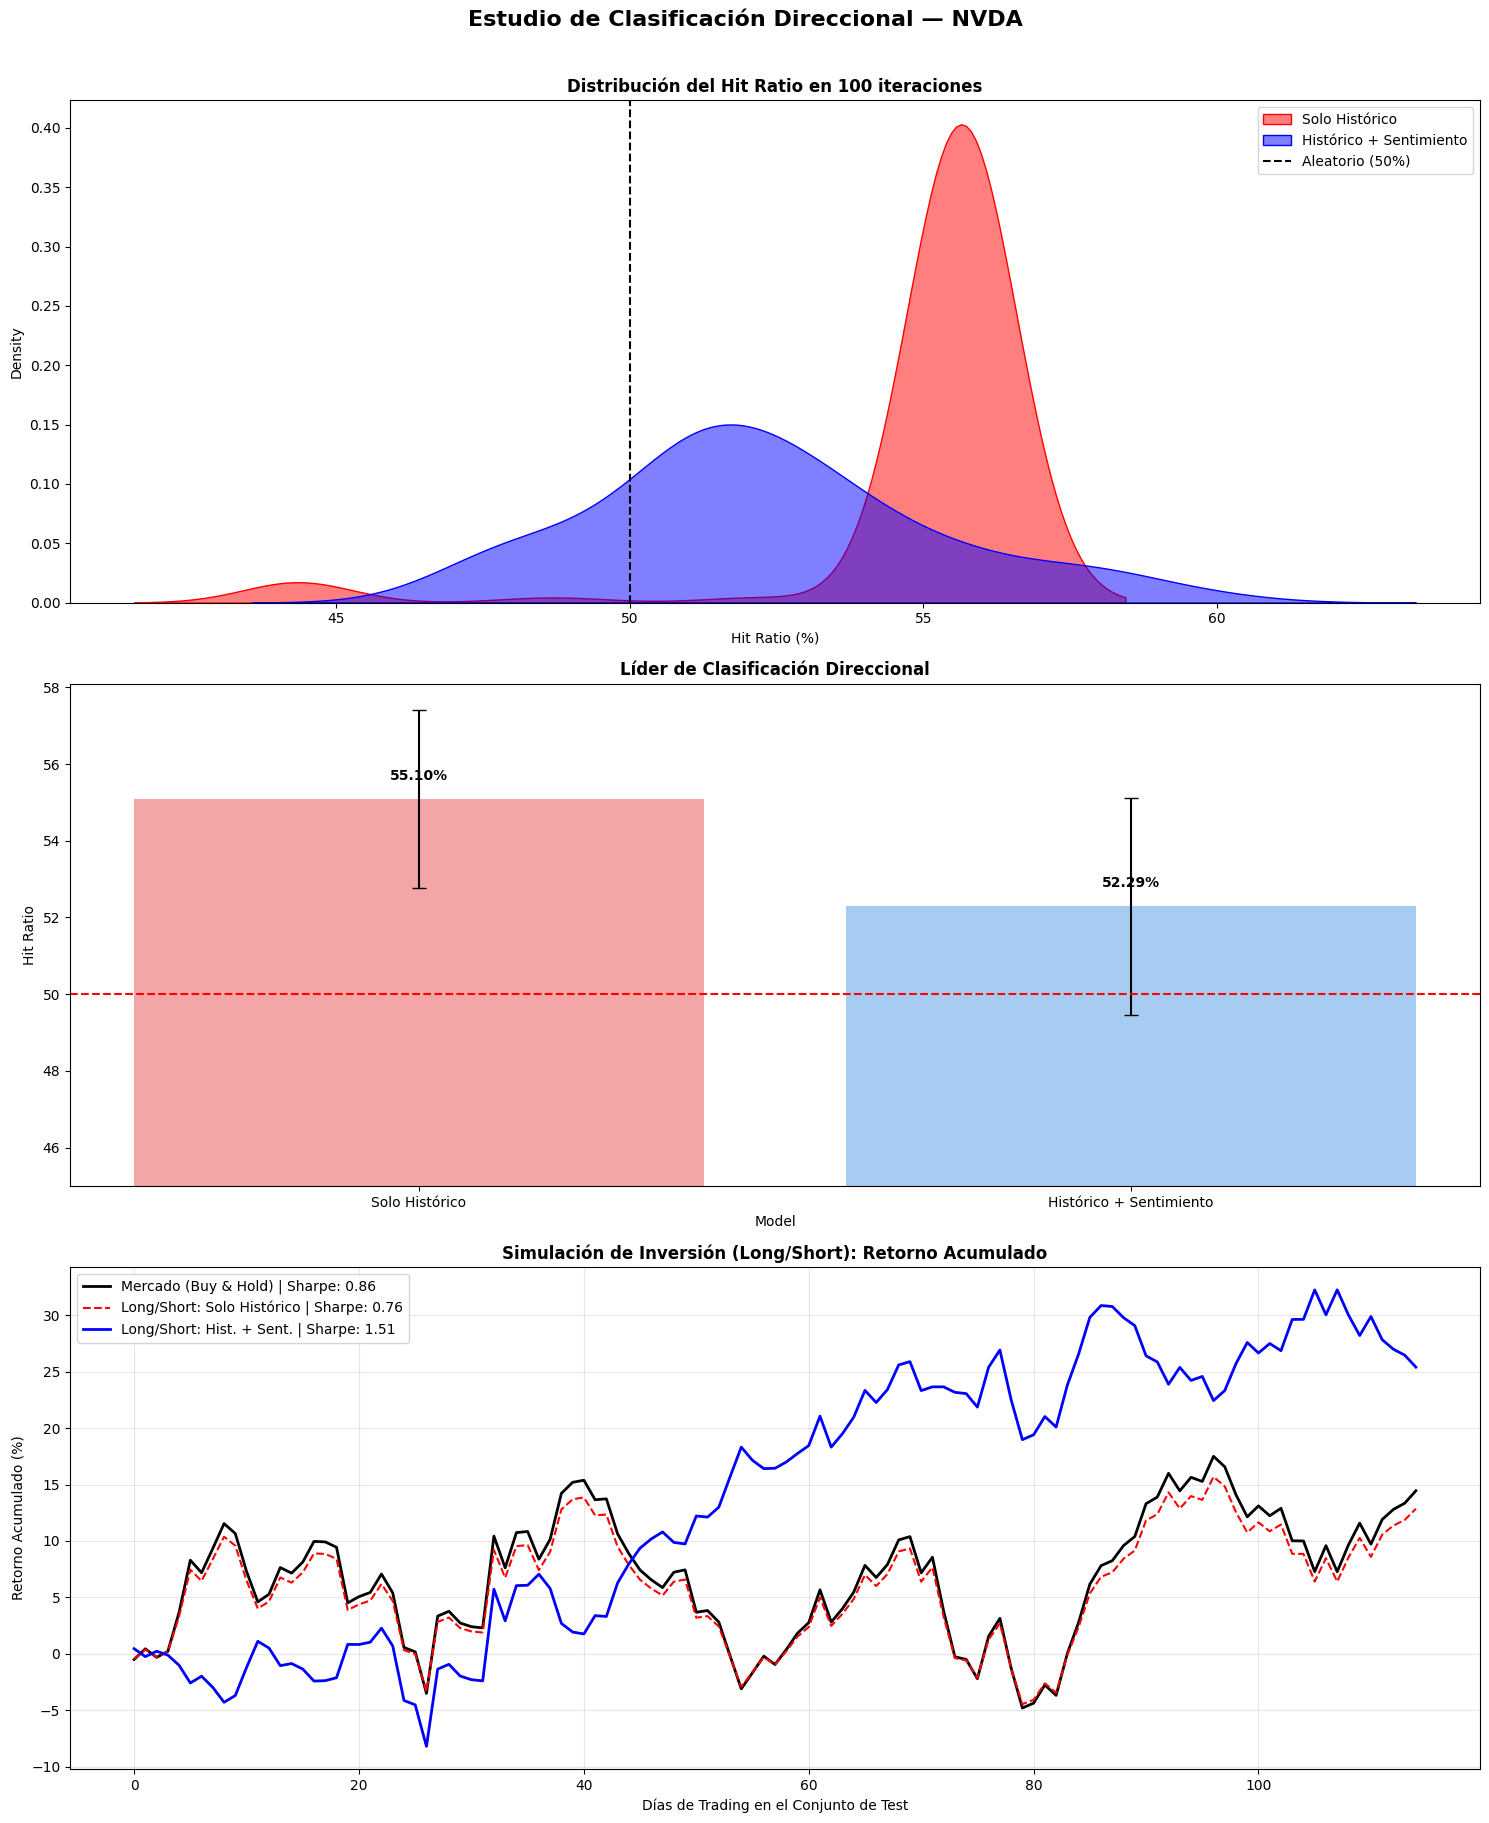

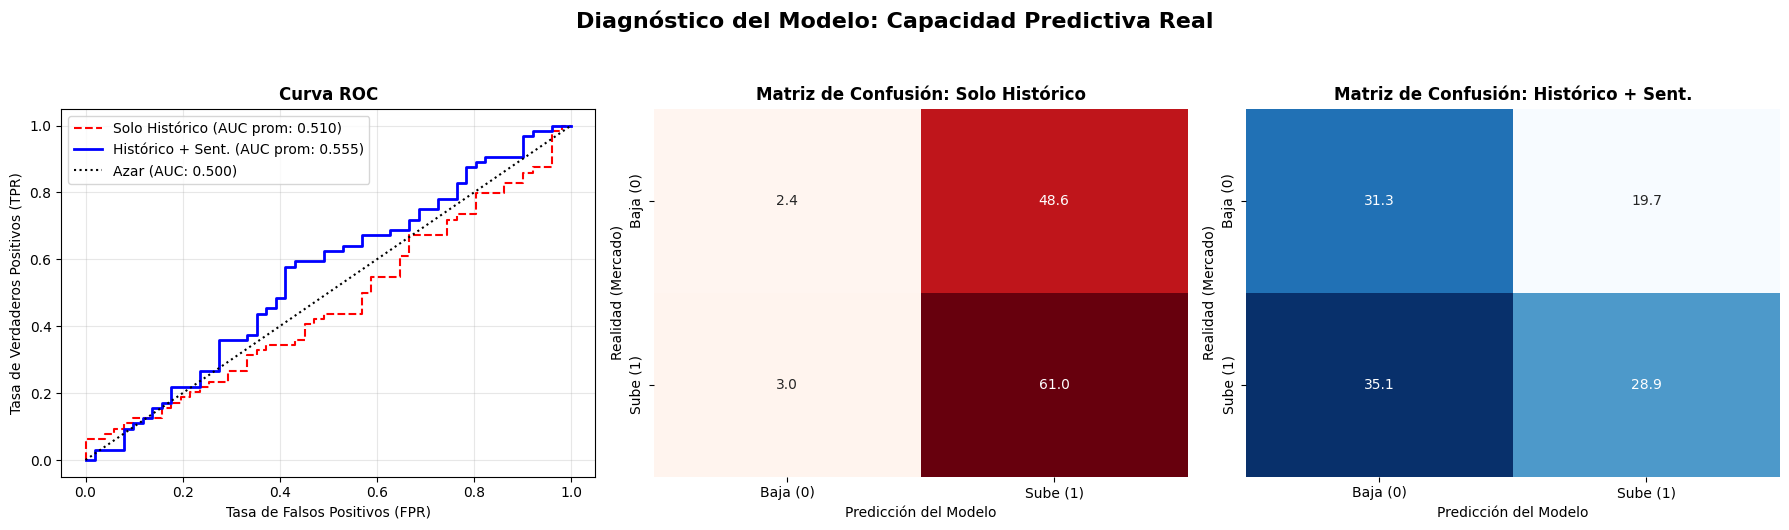

In [ ]:
experimento_clasificacion_direcional(
    ticker_elegido="NVDA",
    ruta_sentimiento=RUTA_3,
    n_runs=100,
    window_size=15
)